# XPCS&XSVS Pipeline for Single-(Gi)-SAXS Run

## Overview

* Setup: load packages/setup path
* Load Metadata & Image Data
* Apply Mask
* Clean Data: shutter open/bad frames
* Get Q-Map
* Get 1D curve
* Define Q-ROI (qr, qz)
* Check beam damage
* One-time Correlation
* Fitting
* Two-time Correlation
The important scientific code is imported from the [chxanalys](https://github.com/yugangzhang/chxanalys/tree/master/chxanalys) and [scikit-beam](https://github.com/scikit-beam/scikit-beam) project. Refer to chxanalys and scikit-beam for additional documentation and citation information.


## CHX Olog Logbook
CHX Olog (https://logbook.nsls2.bnl.gov/11-ID/)  [requires VPN offsite]

## Setup

Import packages for I/O, visualization, and analysis.

In [4]:
from pyCHX.chx_packages import *
%matplotlib notebook
import matplotlib.pyplot as plt
plt.rcParams.update({'figure.max_open_warning': 0})
plt.rcParams.update({ 'image.origin': 'lower'   })
plt.rcParams.update({ 'image.interpolation': 'none'   })
from pyCHX.chx_xpcs_xsvs_jupyter_V1 import *
import itertools

import shutil,glob
from pyCHX.chx_generic_functions import get_roi_mask_qval_qwid_by_shift 
from pyCHX.chx_generic_functions import RemoveHot,create_multi_rotated_rectangle_mask

import sys
import json
from time import localtime, strftime
sys.path.insert(0, "/nsls2/data/chx/shared/CHX_Software/packages/database_processing/") # Need a better way to include these directories
sys.path.insert(0, "/nsls2/data/chx/shared/CHX_Software/packages/AutoRun_functions/")
from database_processing import *
from AutoRun_functions import *

%run /nsls2/data/chx/shared/CHX_Software/packages/environment_management/chx_analysis_setup_test_pyCHX.ipynb
_base_path_ = _base_path_pass_
print(colored("--> overwrote '_base_path_' as %s"%_base_path_,'cyan'))

NoKeyringError: No recommended backend was available. Install a recommended 3rd party backend package; or, install the keyrings.alt package if you want to use the non-recommended backends. See https://pypi.org/project/keyring for details.

'/nsls2/data/chx/proposals/'

## Control Runs Here

In [3]:
scat_geometry = 'saxs'  #suport 'saxs', 'gi_saxs', 'ang_saxs' (for anisotropics saxs or flow-xpcs)


roi_auto =   True #False if True, will automatically create a roi based on the roi_type ( iso/aniso etc), currently only works for SAXS
fit_peak = False #True

analysis_type_auto = True  #if True, will take "analysis type" option from data acquisition func series
qphi_analysis =   False   #if True, will do q-phi (anisotropic analysis for transmission saxs)

isotropic_Q_mask = 'wide' #'wide' # 'normal' # 'wide'  ## select wich Q-mask to use for rings: 'normal' or 'wide'
phi_Q_mask = 'phi_4x_20deg' #'phi_4x_20deg' #'phi_12x_30deg'

    
auto_bst_mask = True # True: if custom 'XPCS_beam_mask.json' does NOT exist in .../cycle/user/masks, create a default polygon mask for beamstop
force_compress = False   #force to compress data 
use_local_disk = True
bin_frame = False   #generally make bin_frame as False
bin_frame_number = 4 # ignored if bin_frame == False
para_compress = True    #parallel compress
# run_fit_form = False    #run fit form factor -> to be removed
mask_outliers = False  #!!
run_waterfall =  False #True #False #True   #run waterfall analysis
run_profile_plot = False  #run prolfile plot for gi-saxs
run_t_ROI_Inten = True  #run  ROI intensity as a function of time
run_get_mass_center = False  # Analysis for mass center of reflective beam center
run_invariant_analysis = False
run_one_time =  True  #run  one-time
cal_g2_error =  False  #True  #calculate g2 signal to noise
run_fit_g2 = False       #run  fit one-time, the default function is "stretched exponential"
fit_g2_func = 'stretched'
run_two_time =   True    #run  two-time
run_four_time = False #True #True #False   #run  four-time
run_xsvs= False # True #False         #run visibility analysis
att_pdf_report = True    #attach the pdf report to CHX olog
qth_interest = 7 #the intested single qth     

use_sqnorm = True    #if True, use sq to normalize intensity  -> what happens if both are true or false?
use_SG = True  #if True, use the Sawitzky-Golay filter of the avg_img for normalization
use_SG_bin_frames =  False   #if True, use the Sawitzky-Golay filter of the (binned) frame for normalization 

use_imgsum_norm= True  #if True use imgsum to normalize intensity for one-time calculatoin -> else it's doing what?
pdf_version='_%s'%strftime("%Y-%m-%d_%H-%M-%S", localtime())  #for pdf report name
run_dose = False #run dose_depend analysis


if scat_geometry == 'gi_saxs':run_xsvs= False;use_sqnorm=False
if scat_geometry == 'gi_waxs':use_sqnorm = False
if scat_geometry != 'saxs':qphi_analysis = False;scat_geometry_ = scat_geometry;roi_auto = False  
else:scat_geometry_ = ['','ang_'][qphi_analysis]+ scat_geometry   
if scat_geometry != 'gi_saxs':run_profile_plot = False

rawdata_link = False # linking raw data in a user sub-folder [sub-folder needs to be created first]

print('scattering geometry: %s/%s  Phi-analysis: %s'%(scat_geometry, scat_geometry_, qphi_analysis))

scattering geometry: saxs/saxs  Phi-analysis: False


### For 'manual' runs: specify uid

In [25]:
#uid = 163201  #(scan num: 142423) (Measurement: 0.02s x 500 fr. Trans:1.0 sample: Membrane )
uid = '2e74c07c' #(scan num: 163340) (Measurement: 0.005s x 200 fr. Trans:1.0 sample: membrane )
uid = '9b63393f' #(scan num: 165968) (Measurement: 0.002s x 500 fr. Trans:1.0 sample: membrane testing Q-range )
#uid = 159757
username_datasec='pass-316793'

#####################################################################################################################
md=get_meta_data(uid)
username = md['user']  #this will be dynamically asigned as a parameter
username = username_datasec  #
cycle = md['cycle']
try:
    users = md['user_group']
except:
    users = []
    
q_mask_name = '' # do NOT specify, will be created based on Q-Phi mask used and become part of hdf5 filename
track_progress = False # IF run by papermill with progress tracking, will automatically switch to 'True'

## Papermill inserts into the cell below:

In [26]:
# Parameters


### creating directory for saving output data 

In [27]:
# Data security modification: username for file creation is now the data_session. Should we fix this in the papermill level?
md=get_meta_data(uid)
username = md['data_session']

In [28]:
default_dir = _base_path_
data_dir0  = create_user_folder(cycle, username, default_dir if alternate_directory is None else alternate_directory)
md=get_meta_data(uid)
uid=md['uid']
print('The current uid for analysis is: %s...'%uid[:8])
data_dir = os.path.join(data_dir0, '%s/'%uid)
os.makedirs(data_dir, exist_ok=True)
print('Results from this analysis will be stashed in the directory %s' % data_dir)
uidstr = 'uid=%s'%uid

Results from this analysis will be stashed in the directory /nsls2/data/chx/proposals/2025-1/pass-315366/Results/
The current uid for analysis is: 9b63393f...
Results from this analysis will be stashed in the directory /nsls2/data/chx/proposals/2025-1/pass-315366/Results/9b63393f-b6c4-4629-99ef-85025f77e5b4/


### set up progress tracking

In [29]:
if 'process_id' in locals(): #if process_id has been inserted by papermill
    settings_dict_={'run_one_time':run_one_time,'run_two_time':run_two_time,'xsvs':run_xsvs}
    prog_dict_file = get_progress_dict_filename(uid,md['cycle'],md['user'],default_dir)
    track_progress = create_new_prog_dict_run_XPCS_SAXS(prog_dict_file=prog_dict_file,process_id=process_id,settings_dict=settings_dict_, verbose=True)
if track_progress:
    print('going to track progress in %s '%prog_dict_file)
    update_prog_dict_run_XPCS_SAXS(prog_dict_file,process_id,progress_key='Load data and compress', progress='start',start_time=time.time(), stop_time=None, verbose=True)
else: print('Not tracking progress...notebook is likely being run outside of papermill')

Not tracking progress...notebook is likely being run outside of papermill


In [30]:
sud = get_sid_filenames_v3(db[uid])
data_fullpath = sud[2]

print ('scan_id, full-uid, data path are:  %s--%s--%s'%(sud[0], sud[1], data_fullpath ))

scan_id, full-uid, data path are:  165968--9b63393f-b6c4-4629-99ef-85025f77e5b4--/nsls2/data/chx/proposals/2025-1/pass-315366/assets/eiger4m-1/2025/03/13/91116c8a-8e56-471b-8e43_2930_master.h5


# Don't Change the lines below here

* get metadata

In [31]:
taus=None;g2=None;tausb=None;g2b=None;g12b=None;taus4=None;g4=None;times_xsv=None;contrast_factorL=None; lag_steps = None 

md = get_meta_data( uid )
md_blue = md.copy()
detectors = sorted(get_detectors(db[uid]))
print('The detectors are:%s'%detectors)
if len(detectors) >1:
    md['detector'] = detectors[0]
    print( md['detector'])

The detectors are:['eiger4m_single_image']


In [32]:
if 'eiger4m' in md['detector'] or md['detector'] == 'image':    
    reverse= True
    rot90= False
elif ('eiger500k' in md['detector']) or ('eiger500K' in md['detector']):    
    reverse= True
    rot90=True
elif 'eiger1m' in md['detector']:    
    reverse= True
    rot90=False
print('Image reverse: %s\nImage rotate 90: %s'%(reverse, rot90))  
try:
    cx , cy = md_blue['beam_center_x'], md_blue['beam_center_y']
    print('(cx,cy) = (%s,%s)'%(cx,cy))
except:
    print('Will find cx,cy later.')

Image reverse: True
Image rotate 90: False
Will find cx,cy later.


### Load ROI defined by "XPCS_Setup" Pipeline

#### Define data analysis type

In [33]:
mask_list = check_roi_masknames(_mask_path_+'ROI_masks/')
iso_masks=[];phi_masks=[]
for m in mask_list:
    if 'phi' in m: phi_masks.append(m)
    else: iso_masks.append(m)

if analysis_type_auto:#if True, will take "analysis type" metadata
    if scat_geometry != 'gi_saxs':
        if md['analysis'] in phi_masks: # specific phi_mask has been requested by data acquisition
            qphi_analysis=True
            phi_Q_mask = md['analysis']
            print('will be using specifically requested Q-Phi-mask: %s'%phi_Q_mask)
        elif md['analysis'] in iso_masks: # specific iso_mask has been requested by data acquisition
            qphi_analysis=False
            isotropic_Q_mask = md['analysis']
            print('will be using specifically requested Q-mask: %s'%isotropic_Q_mask)
        else: # no exact match with existing mask name -> fall back to preselected mask for phi/iso
            qphi_analysis_ = md['analysis'] #if True, will do q-phi (anisotropic analysis for transmission saxs)
            print(md['analysis'])
            if qphi_analysis_ == 'iso':
                qphi_analysis = False
            elif qphi_analysis_ == '':
                qphi_analysis = False
            else:
                qphi_analysis = True    
    else:
        try:
            gisaxs_inc_type = md['analysis']      
        except:
            gisaxs_inc_type = None
            print('There is no analysis in metadata.')
        
print('Will %s qphis analysis.'%['NOT DO','DO'][qphi_analysis]) 

if scat_geometry != 'saxs':qphi_analysis = False;scat_geometry_ = scat_geometry  
else:scat_geometry_ = ['','ang_'][qphi_analysis]+ scat_geometry   
if scat_geometry != 'gi_saxs':run_profile_plot = False     
    
print(scat_geometry_)   


will be using specifically requested Q-Phi-mask: phi_4x_20deg
Will DO qphis analysis.
ang_saxs


## Load Data

In [34]:
try: # preferred: load images as dask_array
    imgs,img_md=load_dask_data(uid,md['detector'], _mask_path_+'pixel_masks/',reverse=reverse,rot90=rot90)
    print(colored('SUCCESSFULLY LOADED DATA AS dask-array!','green'))
except:
    print(colored('COULD NOT LOAD DATA AS dask-array, reverting to slow data loading....','red'))
    imgs = load_data(uid,md['detector'],reverse=reverse,rot90=rot90)
    img_md=imgs.md
    print(colored('COULD NOT LOAD DATA AS dask-arry, falling back to slow data loading....','red'))
imgs

SUCCESSFULLY LOADED DATA AS dask-array!


dask.array<getitem, shape=(500, 2167, 2070), dtype=uint16, chunksize=(10, 2167, 2070), chunktype=numpy.ndarray>

In [35]:
md.update( img_md )
md['number of images']  = int(md['number of images'])
pixel_mask=np.ones( np.shape(imgs[0]))
if reverse and not rot90:
    md['beam_center_y']=np.shape(imgs[0])[0]- md['beam_center_y']
if reverse and rot90:
    xc=md['beam_center_y'];yc=md['beam_center_x']
    yc=np.shape(imgs[0])[0]-yc
    xc=np.shape(imgs[0])[1]-xc
    md['beam_center_y']=yc;md['beam_center_x']=xc
if rot90 and not reverse:
    raise Exception('ERROR: somebody still needs to figure out the transformation for reverse=%s and rot90=%s!'%(reverse,rot90))
print('Beam Center: xc: %s  yc: %s'%(md['beam_center_x'],md['beam_center_y']))

Beam Center: xc: 1863.0  yc: 265.0


### create aggregate image of OAV images

In [36]:
save_oavs = False
found_oavs = False
for d in detectors:
    if 'oav' in d:
        found_oavs=True   
    
if found_oavs:
    try:
        save_oavs_tifs_v2(  uid, data_dir )
        save_oavs = True
        print('successfully created aggregate image from individual OAV images')
    except:
        print('Failed to create aggregate image from individual OAV images -> OAV images will not be attached to Olog.')  

### load detector mask

In [37]:
detector_mask_path = _mask_path_+'pixel_masks/'
detector_mask_filename = 'detector_mask_%s.json'%md['detector'].split('_')[0]
json_open=open(detector_mask_path+detector_mask_filename)
det_mask_dict=json.load(json_open)
for kk,k in enumerate(list(det_mask_dict['masks'].keys())):
    if kk == 0:
        det_mask=np.array(det_mask_dict['masks'][k],dtype=bool)
    else:
        det_mask*=np.array(det_mask_dict['masks'][k],dtype=bool)

### load beam mask dictionary and re-create polygon mask for current detector and direct beam position

In [38]:
beam_mask_filename = 'XPCS_beam_mask.json'
mask_path =default_dir+'%s/%s/masks/'%(cycle,username)
try:
    json_open=open(mask_path+beam_mask_filename)
    polygon_dict=json.load(json_open)
    print('loading user specified mask from %s'%(mask_path+beam_mask_filename))
except:
    if auto_bst_mask:
        if scat_geometry == 'saxs':
            print('automatically creating a mask for beamstop and streaks')
            polygon_dict={'masks':{'partial_mask':{'x_off': [0, -80],'y_off': [0, 0], 'wy_left': [20, 0],'wy_right': [10, 36],'wx_up': [20, 0],'wx_down': [20, 0],'center_radius': [0, 0]}}}
        elif scat_geometry == 'gi_saxs':
            polygon_dict={'masks':{'partial_mask':{'x_off': [0, 0],'y_off': [0, 0], 'wy_left': [0, 0],'wy_right': [0, 0],'wx_up': [36, 0],'wx_down': [36, 0],'center_radius': [0, 0]}}}
    else:
        raise Exception('failed to load user specified mask from %s'%(mask_path+beam_mask_filename))

automatically creating a mask for beamstop and streaks


In [39]:
print('polygon masks: (could edit dictionary entries to modify mask here)')
polygon_dict['masks']

polygon masks: (could edit dictionary entries to modify mask here)


{'partial_mask': {'x_off': [0, -80],
  'y_off': [0, 0],
  'wy_left': [20, 0],
  'wy_right': [10, 36],
  'wx_up': [20, 0],
  'wx_down': [20, 0],
  'center_radius': [0, 0]}}

In [40]:
polygon_dict['masks']['partial_mask']['wy_right']= [8, 26]
polygon_dict['masks']['partial_mask']['wx_up']= [8, 0]
polygon_dict['masks']['partial_mask']['wx_down']= [8, 0]
polygon_dict['masks']['partial_mask']['wy_left']= [8, 0]
polygon_dict['masks']['partial_mask']['x_off'] = [0, -63]

#### re-create multi-polygon mask:

In [41]:
polygon_mask=np.ones_like( det_mask , dtype = bool)
if 'rmask' in list(polygon_dict['masks'].keys()):
    rmask_dict={}
    for aa,a in enumerate(polygon_dict['masks']['rmask']['angles']):
        rmask_dict[a] = create_multi_rotated_rectangle_mask( pixel_mask, 
                                center= [ md['beam_center_x'], md['beam_center_y']   ], length=polygon_dict['masks']['rmask']['length'][aa], width=polygon_dict['masks']['rmask']['width'][aa], angles=[a] )

    for aa,a in enumerate(list(rmask_dict.keys())):
        if aa == 0:
            rmask = rmask_dict[a]
        else:
            rmask*=rmask_dict[a]
    polygon_mask*=rmask
if 'partial_mask' in list(polygon_dict['masks'].keys()):
    partialmask_dict={}
    for ii,i in enumerate(range(len(polygon_dict['masks']['partial_mask']['x_off']))[:]): # [:] use all elements in list; [:2] use the first two elements in list, etc. to create masks
        partialmask_dict[ii] = create_cross_mask(  pixel_mask,center= [ md['beam_center_x']+polygon_dict['masks']['partial_mask']['x_off'][i], md['beam_center_y']+polygon_dict['masks']['partial_mask']['y_off'][i]   ], 
                                wy_left= polygon_dict['masks']['partial_mask']['wy_left'][i], wy_right= polygon_dict['masks']['partial_mask']['wy_right'][i], 
                                wx_up= polygon_dict['masks']['partial_mask']['wx_up'][i], wx_down= polygon_dict['masks']['partial_mask']['wx_down'][i],center_radius= polygon_dict['masks']['partial_mask']['center_radius'][i])
        
    for i in list(partialmask_dict.keys()):
        if i == 0:
            partial_mask = partialmask_dict[i]
        else:
            partial_mask*=partialmask_dict[i]
    polygon_mask*=partial_mask
if 'window_mask' in list(polygon_dict['masks'].keys()):
    try: # center_circle has been renamed to center_disk at some point -> with try this works on old and new environements
        window_shadow  = ~create_cross_mask(  pixel_mask, center=[md['beam_center_x'],md['beam_center_y']],
                           wy_left= 0, wy_right= 0, 
                             wx_up= 0, wx_down= 0,center_disk=True, center_radius= polygon_dict['masks']['window_mask']['center_radius'])
    except:
        window_shadow  = ~create_cross_mask(  pixel_mask, center=[md['beam_center_x'],md['beam_center_y']],
                           wy_left= 0, wy_right= 0, 
                             wx_up= 0, wx_down= 0,center_circle=True, center_radius= polygon_dict['masks']['window_mask']['center_radius'])
        print('using "create_cross_mask" for older python environments')
    polygon_mask*=window_shadow

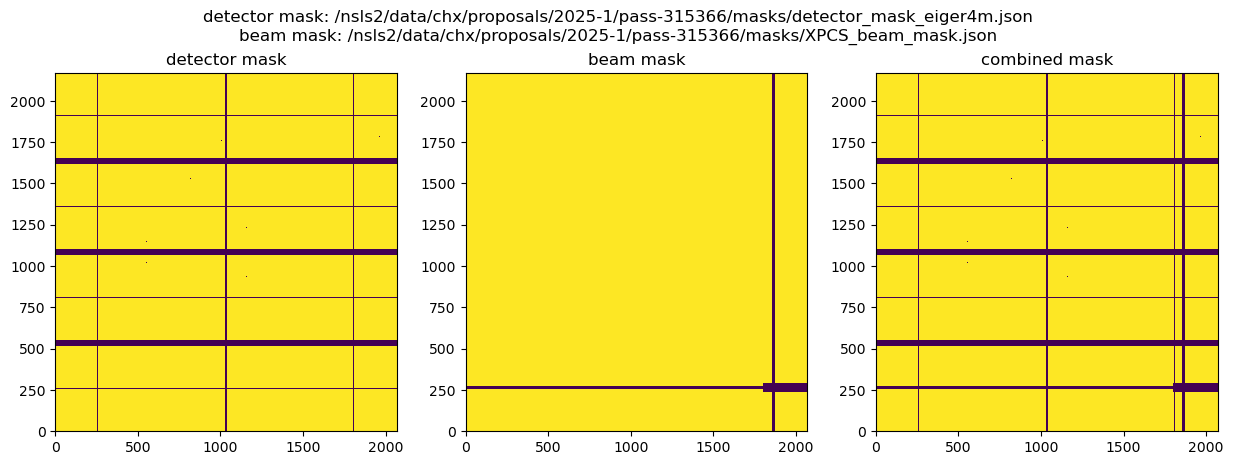

In [42]:
fig,ax = plt.subplots(1,3,figsize=(15,5))
plt.suptitle('detector mask: %s\nbeam mask: %s'%(mask_path+detector_mask_filename,mask_path+beam_mask_filename))

plt.subplot(1,3,1)
plt.title('detector mask')
plt.imshow( det_mask)
plt.subplot(1,3,2)
plt.title('beam mask')
plt.imshow(polygon_mask)
plt.subplot(1,3,3)
plt.title('combined mask')
mask=polygon_mask*det_mask    
plt.imshow(mask)
mask_copy=mask.copy()

In [44]:
print_dict( md,  ['suid', 'number of images', 'uid', 'scan_id', 'start_time', 'stop_time', 'sample', 'Measurement',
                  'acquire period', 'exposure time',  
         'det_distance', 'beam_center_x', 'beam_center_y', ] )

suid--> 9b63393f-b6c4-4629-99ef-85025f77e5b4
number of images--> 500
uid--> 9b63393f-b6c4-4629-99ef-85025f77e5b4
scan_id--> 165968
start_time--> 2025-03-13 17:58:32
stop_time--> 2025-03-13 17:58:38
sample--> membrane
Measurement-->  0.002s x 500 fr. Trans:1.0 sample: membrane testing Q-range
acquire period--> 0.002
exposure time--> 0.002
beam_center_x--> 1863.0
beam_center_y--> 265.0


## Overwrite Some Metadata if Wrong Input

### Define incident beam center (also define reflection beam center for gisaxs)

In [47]:
if scat_geometry =='gi_saxs':
    inc_x0 =  md['beam_center_x'] 
    inc_y0 =  imgs[0].shape[0] - md['beam_center_x']      
    #1147 ,1550
    refl_x0 =     md['beam_center_x']  
    refl_y0 =   1600.645 #  calculated for an incidence angle of 0.32 deg   
    
    print( "inc_x0, inc_y0, ref_x0,ref_y0 are: %s %s %s %s."%(inc_x0, inc_y0, refl_x0, refl_y0) )
else:
    inc_y0 = md['beam_center_y']
    inc_x0 = md['beam_center_x']
    
#     if md['detector'] =='eiger4m_single_image' or md['detector'] == 'image' or md['detector']=='eiger1m_single_image':    
#         inc_x0 =  imgs[0].shape[0] - md['beam_center_y']   
#         inc_y0=   md['beam_center_x']
#     elif md['detector'] =='eiger500K_single_image':    
#         #inc_y0 =  imgs[0].shape[1] - md['beam_center_y']   ### Changed this...not clear why
#         #inc_x0 =   imgs[0].shape[0] - md['beam_center_x']
#         inc_x0 = imgs[0].shape[1]-md['beam_center_y']
#         inc_y0 = md['beam_center_x']
        
    
#     print(inc_x0, inc_y0)

    ###for this particular uid, manually give x0/y0
    #inc_x0 = 1041
    #inc_y0 = 1085

In [48]:
dpix, lambda_, Ldet,  exposuretime, timeperframe, center = check_lost_metadata(
    md, md['number of images'], inc_x0 = inc_x0, inc_y0=   inc_y0, pixelsize = 7.5*10*(-5) )
if scat_geometry =='gi_saxs':center=center[::-1]

setup_pargs=dict(uid=uidstr, dpix= dpix, Ldet=Ldet, lambda_= lambda_, exposuretime=exposuretime,
        timeperframe=timeperframe, center=center, path= data_dir)
print_dict( setup_pargs )


Beam_center_x has been changed to 265.0. (no change in raw metadata): 
Beam_center_y has been changed to 1863.0.  (no change in raw metadata): 
uid--> uid=9b63393f-b6c4-4629-99ef-85025f77e5b4
dpix--> 0.075
Ldet--> 10003.0
lambda_--> 1.284810346458034
exposuretime--> 0.001997
timeperframe--> 0.002
center--> [1863, 265]
path--> /nsls2/data/chx/proposals/2025-1/pass-315366/Results/9b63393f-b6c4-4629-99ef-85025f77e5b4/


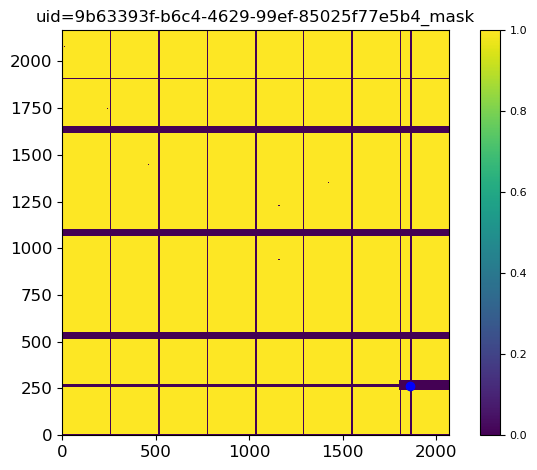

In [49]:
show_img(np.array(mask,dtype=int),image_name = uidstr + '_mask', save=False, path=data_dir, aspect=1, center=center)
mask_load=mask.copy()

imgsa = apply_mask( imgs, np.array(mask,dtype=int) )

## Check several frames average  intensity

#### Load ROI mask depending on data analysis type

In [50]:
roi_date = 'N.A'

if scat_geometry =='saxs':
    ## For auto load roi mask
    if roi_auto: 
        general_path = _mask_path_+'ROI_masks/'
        if qphi_analysis ==  False:
            fp = general_path + 'general_roi_mask_%s.json'%isotropic_Q_mask
            q_mask_name = isotropic_Q_mask
        elif qphi_analysis:
            fp = general_path + 'general_roi_mask_%s.json'%phi_Q_mask
            q_mask_name = phi_Q_mask        
        
        f = open(fp)  ### load json file
        tmp = json.load(f);f.close()
        mask_dict=json.loads(tmp);del tmp
        roi_mask0 = np.array(mask_dict['roi_mask'])  
        old_cen=mask_dict['original center'] 
        ## NOTE: new_"cen below" is actually ignored: function is hardcoded to use setup_pargs['center'] as center ####
        # as the roi masks were not created using the physically correct orientations of the detectors, we'll need to fudge something here...
        if "eiger500k" in md['detector']:
            setup_pargs['center']=center[::-1]
        if "eiger4m" in md['detector']:
            setup_pargs['center']=center[::-1]
        roi_mask, qval_dict, qwid_dict = get_roi_mask_qval_qwid_by_shift( 
                        new_cen=[0,0], new_mask= mask, old_cen=old_cen,
                                    old_roi_mask=roi_mask0, limit_qnum= 180,
                                    setup_pargs= setup_pargs,  geometry = scat_geometry_,
                                    ) 
        ## undo fudging:
        setup_pargs['center']=center
 
    else: 
        if qphi_analysis ==  False:
            if isotropic_Q_mask == 'normal':
                #print('Here')
                q_mask_name='rings'
                if "eiger4m" in md['detector'] or md['detector'] == 'image': #for 4M 
                    fp = roi_path + 'roi_mask_%s_4M_norm.pkl'%roi_date                 

                elif ("eiger500k" in md['detector']) or ("eiger500K" in md['detector']): #for 500K   
                    fp = roi_path + 'roi_mask_%s_500K_norm.pkl'%roi_date   


            elif isotropic_Q_mask == 'wide':
                q_mask_name='wide_rings'
                if "eiger4m" in md['detector'] or md['detector'] == 'image': #for 4M   
                    fp = roi_path + 'roi_mask_%s_4M_wide.pkl'%roi_date   
                elif ("eiger500k" in md['detector']) or ("eiger500K" in md['detector']): #for 500K   
                    fp = roi_path + 'roi_mask_%s_500K_wide.pkl'%roi_date   


        elif qphi_analysis:
            if phi_Q_mask =='phi_4x_20deg':
                q_mask_name='phi_4x_20deg'
                if md['detector'] =='eiger4m_single_image' or md['detector'] == 'image': #for 4M 
                    fp = roi_path + 'roi_mask_%s_4M_phi_4x_20deg.pkl'%roi_date   
                    fp = roi_path + 'roi_mask_%s_4M_phi_24x_15deg.pkl'%roi_date   
                    
                elif (md['detector'] =='eiger500k_single_image') or (md['detector'] == "eiger500K_single_image"): #for 500K 
                    fp = roi_path + 'roi_mask_%s_500K_phi_4x_20deg.pkl'%roi_date   

          
        roi_mask,qval_dict = cpk.load( open(fp, 'rb' )  )  #for load the saved roi data
        print(fp)

## Gi_SAXS 
elif scat_geometry =='gi_saxs':    
    # static mask        
    fp = default_dir + md['cycle'] +'/masks/uid=%s_roi_masks.pkl'%ss
    roi_masks,qval_dicts = cpk.load( open(fp, 'rb' )  )  #for load the saved roi data    
    print('The static mask is: %s.'%fp)    

    fp = default_dir + md['cycle'] +'/masks/uid=%s_roi_mask.pkl'%(ss)
    roi_mask,qval_dict = cpk.load( open(fp, 'rb' )  )  #for load the saved roi data
    print('The dynamic mask is: %s.'%fp)
    # q-map
    fp = default_dir + md['cycle'] +'/masks/uid=%s_qmap.pkl'%(ss)
    #print(fp)
    qr_map, qz_map, ticks, Qrs, Qzs,  Qr, Qz, inc_x0,refl_x0, refl_y0 = cpk.load( open(fp, 'rb' )  )
    print('The qmap is: %s.'%fp)
    
## WAXS 
elif scat_geometry =='gi_waxs': 
    
    fp =  default_dir + md['cycle'] +'/masks/uid=278c0df1_roi_mask.pkl'
    
    roi_mask,qval_dict = cpk.load( open(fp, 'rb' )  )  #for load the saved roi data

roi_mask2 = roi_mask.copy()

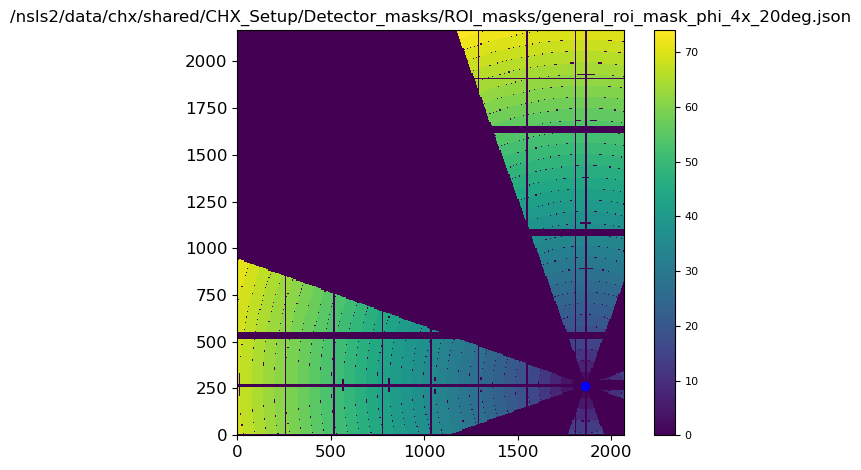

In [51]:
#roi_mask = shift_mask(roi_mask, 10,30)  #if shift mask to get new mask
show_img(roi_mask, aspect=1.0, image_name = fp, center=center,vmin=0)


In [54]:
img_choice_N = 5
img_samp_index = random.sample(  range(md['number of images']), img_choice_N) 
avg_img =  get_avg_img( imgsa, img_samp_index, plot_ = False, uid =uidstr)
if avg_img.max() == 0:
    print('There are no photons recorded for this uid: %s'%uid)
    print('The data analysis should be terminated! Please try another uid.')

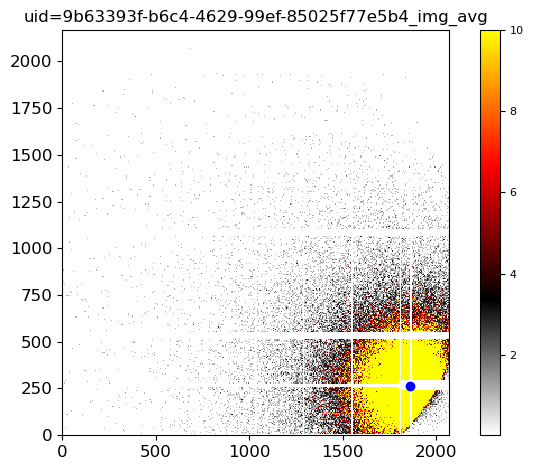

In [55]:
show_img( imgsa[ 5],  vmin = .01, vmax = 10, logs=False, aspect=1, #save_format='tif',
         image_name= uidstr + '_img_avg',  save=True, path=data_dir, cmap=cmap_albula,center=center)

## Compress Data
* Generate a compressed data with filename
* Replace old mask with a new mask with removed hot pixels
* Do average image
* Do each image sum
* Find badframe_list for where image sum above bad_pixel_threshold
* Check shutter open frame to get good time series


In [56]:
compress=True
photon_occ = len( np.where(avg_img)[0] ) / ( np.shape(imgsa[0])[0]*np.shape(imgsa[0])[1]*md['number of images'])
#compress =  photon_occ < .4  #if the photon ocupation < 0.5, do compress
print ("The non-zeros photon occupation is %s."%( photon_occ))
print("Will " + 'Always ' + ['NOT', 'DO'][compress]  + " apply compress process.")

The non-zeros photon occupation is 0.0005503291578330201.
Will Always DO apply compress process.


In [57]:
if  "eiger4m" in md['detector'] or md['detector'] == 'image':    
    good_start =    0 #make the good_start at least 0
elif ("eiger500k" in md['detector']) or ("eiger500K" in md['detector']): 
    good_start = 0#100  #5  #make the good_start at least 0
elif "eiger1m" in md['detector'] or md['detector'] == 'image':    
    good_start =    0    
    
if bin_frame:
    bin_frame_number=bin_frame_number
    acquisition_period = md['acquire period']
    timeperframe = acquisition_period * bin_frame_number
else:
    bin_frame_number =1
print('first frame to be used: %s\nframe binning: %s'%(good_start,bin_frame_number))

first frame to be used: 0
frame binning: 1


### change compression behavior if necessary

In [58]:
#force_compress = False
#use_local_disk = True
print('force compression: %s  use local disk: %s'%(force_compress,use_local_disk))

force compression: False  use local disk: True


Using already created compressed file with filename as :/nsls2/data/chx/proposals/2025-1/pass-315366/Compressed_Data/uid_9b63393f-b6c4-4629-99ef-85025f77e5b4.cmp.
The good_start frame number is: 0 
uid=9b63393f-b6c4-4629-99ef-85025f77e5b4_fra_0_500
Total time: 0.345 sec


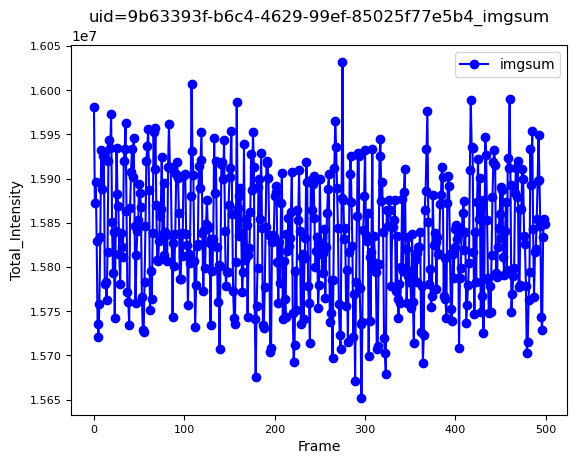

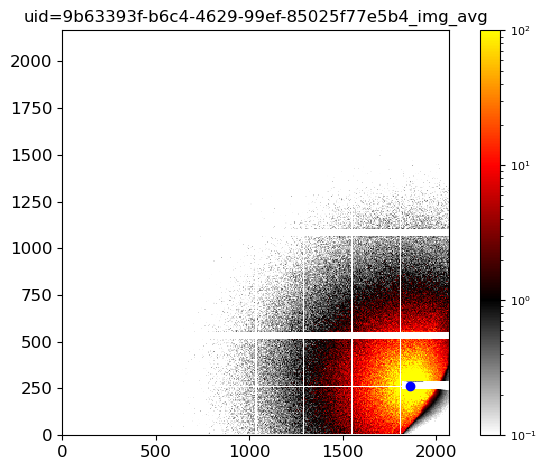

In [59]:
imgs_=np.ones(md['number of images']) #just need to fake an array of appropriate length for the compression routine

import time
t0= time.time()

# if not use_local_disk:
#     cmp_path = '/nsls2/data/chx/legacy/Compressed_Data'
# else:
#     cmp_path = '/tmp_data/compressed'
#     print(here)
    
    
cmp_path = data_dir0[:-8] + 'Compressed_Data' 
if bin_frame_number==1:   
    cmp_file = '/uid_%s.cmp'%md['uid']
else:
    cmp_file = '/uid_%s_bined--%s.cmp'%(md['uid'],bin_frame_number)

#force_compress = True
filename = cmp_path + cmp_file  
mask2, avg_img, imgsum, bad_frame_list = compress_eigerdata(imgs_, det_mask, md, filename,   ########## NEW: mask -> det_mask
         force_compress= force_compress,  para_compress= para_compress,  bad_pixel_threshold = 1e14,
                                    reverse=reverse, rot90=rot90, nobytes=4,
                        bins=bin_frame_number, num_sub= 100, num_max_para_process= 500, with_pickle=True,
                        direct_load_data =use_local_disk, data_path = data_fullpath, new_path = '/tmp/' )                                  
                                                         
min_inten = 10    
good_start = max(good_start, np.where( np.array(imgsum) > min_inten )[0][0] )    
print ('The good_start frame number is: %s '%good_start)

FD = Multifile(filename, good_start, len(imgs_)//bin_frame_number )


uid_ = uidstr + '_fra_%s_%s'%(FD.beg, FD.end)
print( uid_ )
plot1D( y = imgsum[ np.array( [i for i in np.arange(good_start, len(imgsum)) if i not in bad_frame_list])],
       title =uidstr + '_imgsum', xlabel='Frame', ylabel='Total_Intensity', legend='imgsum'   )
Nimg = int( md['number of images']/bin_frame_number )
run_time(t0)

# mask2 =  mask * pixel_mask * Chip_Mask
mask_copy = mask.copy()
mask_copy2 = mask.copy()

#avg_img *= mask

show_img( avg_img,  vmin=1e-1, vmax= 1e2, logs=True, aspect=1, #save_format='tif',
         image_name= uidstr + '_img_avg',  save=True, 
         path=data_dir, center=center, cmap = cmap_albula )

### Linking Raw data in 'rawdata' folder [folder needs to be created first]

In [60]:
if(rawdata_link):
    #data_fullpath - h5 file
    #filename - cmp file
    rawdata_folder = data_dir0[:-8]+'rawdata'
    h5_linkname = rawdata_folder+'/'+cmp_file[:-4]+'.h5'
    
    #print('The raw data directory is: %s'%rawdata_folder)
    #print('The hdf5 file is: %s'%data_fullpath)
    #print('The cmp file is: %s'%filename[:])
    #print('The h5 link name is: %s'%h5_linkname)
    !ln -s {data_fullpath} {h5_linkname}
    !ln -s {filename} {rawdata_folder+'/'}

In [61]:
if track_progress:
    update_prog_dict_run_XPCS_SAXS(prog_dict_file,process_id,progress_key='Load data and compress', progress='stop',start_time=None, stop_time=time.time(), verbose=True)
    if settings_dict_['run_one_time']:
        update_prog_dict_run_XPCS_SAXS(prog_dict_file,process_id,progress_key='run_one_time', progress='start',start_time=time.time(), stop_time=None, verbose=True)

## Get bad frame list by a polynominal fit

In [62]:
good_end= None # 2000  
if good_end is not None:
    FD = Multifile(filename, good_start, min( len(imgs_)//bin_frame_number, good_end) )
    uid_ = uidstr + '_fra_%s_%s'%(FD.beg, FD.end)
    print( uid_ )
    

In [63]:
re_define_good_start =False
if re_define_good_start:
    good_start = 180
    #good_end = 19700
    good_end = len(imgs_)
    FD = Multifile(filename, good_start, good_end) 
    uid_ = uidstr + '_fra_%s_%s'%(FD.beg, FD.end)
    print( FD.beg, FD.end)

/nsls2/data/chx/shared/CHX_Software/packages/pyCHX/chx_generic_functions.py:2794: RankWarning: Polyfit may be poorly conditioned
  pol = np.polyfit(x, y, order)


The bad frame list length is: 0


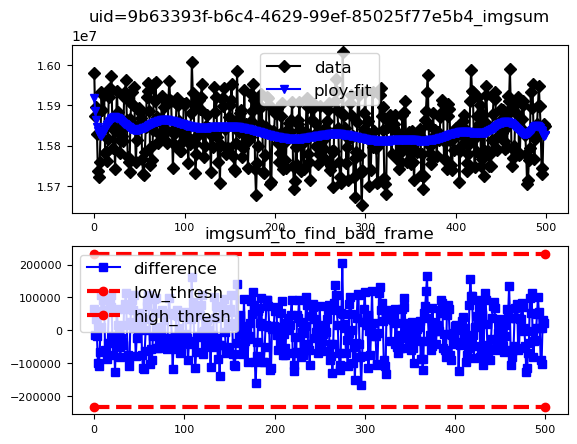

In [64]:
bad_frame_list =  get_bad_frame_list( imgsum, fit='both',  plot=True,polyfit_order = 30,                                      
                        scale= 3.5,  good_start = good_start, good_end=good_end, uid= uidstr, path=data_dir)

print( 'The bad frame list length is: %s'%len(bad_frame_list) )

### Create new mask by masking the bad pixels and get new avg_img

In [65]:
imgsum_y = imgsum[ np.array( [i for i in np.arange( len(imgsum)) if i not in bad_frame_list])]
imgsum_x = np.arange( len( imgsum_y))
save_lists(  [imgsum_x, imgsum_y], label=['Frame', 'Total_Intensity'],
           filename=uidstr + '_img_sum_t', path= data_dir  )
print('number of bad pixels masked: %s'%len(imgsum_y))

number of bad pixels masked: 500


### Plot time~ total intensity of each frame

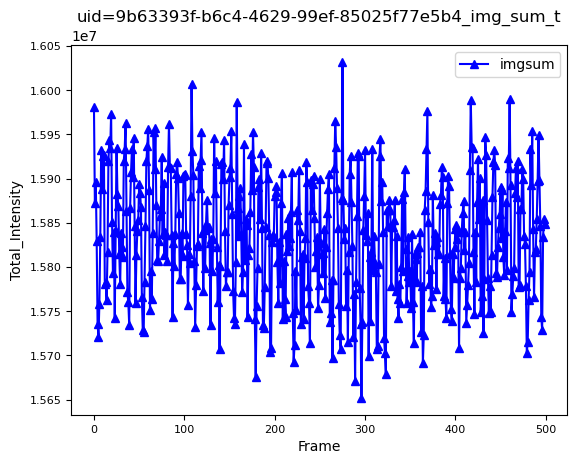

In [66]:
plot1D( y = imgsum_y, title = uidstr + '_img_sum_t', xlabel='Frame', c='b',
       ylabel='Total_Intensity', legend='imgsum', save=True, path=data_dir)

## Get Dynamic Mask (currently designed for 500K)

# NEED ALL Detectors! There are 3 bit-depth levels!
### check Dectris documentation: 16/8/4 bit(?)

In [67]:
if  "eiger4m" in md['detector'] or md['detector'] == 'image':    
    pass
elif ("eiger500k" in md['detector']) or ("eiger500K" in md['detector']):  
    if md['eiger500K_single_cam_acquire_period'] <= 0.00015:  #will check this logic
        if imgs[0].dtype == 'uint8':
            print('Create dynamic mask for 500K due to 9K data acquistion!!!')
            #bdp = find_bad_pixels_FD( bad_frame_list, FD, img_shape = avg_img.shape, threshold= 15 )  
            bdp = find_bad_pixels_FD( np.arange(Nimg), FD, img_shape = avg_img.shape, threshold= 15 )  
            mask = mask_copy2.copy()
            mask *=bdp 
            mask_copy = mask.copy()
            show_img(  np.array(mask,dtype=int), image_name='New Mask_uid=%s'%uid, aspect=1 )

## SAXS Scattering Geometry

In [68]:
setup_pargs['center'] = center[::-1]

/nsls2/data/chx/shared/CHX_Software/packages/pyCHX/XPCS_SAXS.py:537: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax1.set_ylim(ylim)


Removed 0 hot pixels.


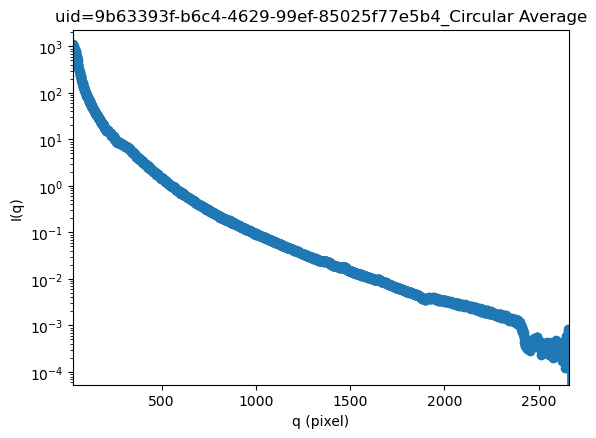

In [69]:
if scat_geometry =='saxs':
    outlier_threshold = 5.5 # change here, if necessary
    maximum_outlier_fraction = .1
    
    roi_mask = roi_mask2.copy()
    ## Get circular average| * Do plot and save q~iq
    mask = mask_copy.copy()
    hmask = create_hot_pixel_mask( avg_img, threshold = 2e8, center=center, center_radius= 100)
    mask =np.array( mask * hmask, dtype=bool)
    
    if mask_outliers:
        hhmask = outlier_mask(avg_img,mask,roi_mask,outlier_threshold = outlier_threshold, maximum_outlier_fraction = maximum_outlier_fraction,verbose=False,plot=False)
        mask =np.array( mask * hhmask, dtype=bool)
        
    qp_saxs, iq_saxs, q_saxs = get_circular_average( avg_img * det_mask , mask * hmask, save=True,
    #qp_saxs, iq_saxs, q_saxs = get_circular_average( avg_img * det_mask*mask , mask, save=True,
                                                    pargs=setup_pargs  )
    plot_circular_average( qp_saxs, iq_saxs, q_saxs,  pargs=setup_pargs,  show_pixel=True,
                      xlim=[qp_saxs.min(), qp_saxs.max()*1.0], ylim = [iq_saxs.min(), iq_saxs.max()*2] )
    
    print('Removed %s hot pixels.'%len(np.nonzero(hmask-1)[0]))
    roi_mask = roi_mask * mask

/nsls2/data/chx/shared/CHX_Software/packages/pyCHX/XPCS_SAXS.py:1633: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  axes.set_ylim(ylim)


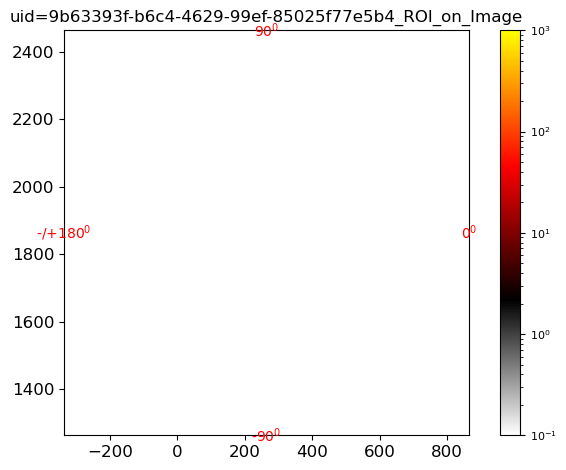

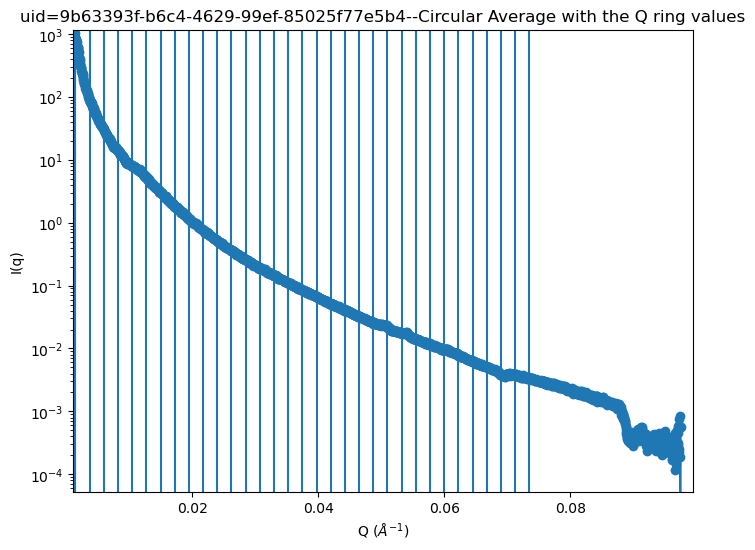

In [70]:
if scat_geometry =='saxs':  
    qr = np.array( [qval_dict[k][0] for k in sorted( qval_dict.keys())] )
    if qphi_analysis ==  False:
        try:
            qr_cal, qr_wid = get_QrQw_From_RoiMask( roi_mask, setup_pargs  ) 
            print(len(qr))         
            if (qr_cal - qr).sum() >=1e-3:
                print( 'The loaded ROI mask might not be applicable to this UID: %s.'%uid)
                print('Please check the loaded roi mask file.')
        except:
            print('Something is wrong with the roi-mask. Please check the loaded roi mask file.')            
            
    
    show_ROI_on_image( avg_img*roi_mask, roi_mask, center, label_on = False, rwidth = 600, alpha=.9,  
                 save=True, path=data_dir, uid=uidstr, vmin= 1e-1,
                 vmax= 1e3, #np.max(avg_img),
                 aspect=1,
                 show_roi_edge=True,     
                 show_ang_cor = True) 
    plot_qIq_with_ROI( q_saxs, iq_saxs, np.unique(qr), logs=True, uid=uidstr, 
                      xlim=[q_saxs.min(), q_saxs.max()*1.02],#[0.0001,0.08],
                  ylim = [iq_saxs.min(), iq_saxs.max()*1.02],  save=True, path=data_dir)
    

# Time Depedent I(q) Analysis

/nsls2/data/chx/shared/CHX_Software/packages/pyCHX/XPCS_SAXS.py:874: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(kwargs["ylim"])


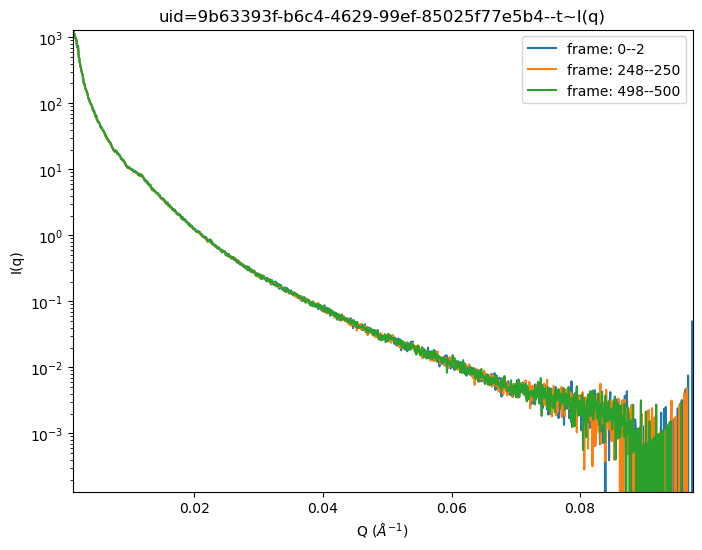

In [71]:
if scat_geometry =='saxs':
    slice_num=3
    slice_width=2
    Nimg = FD.end - FD.beg 
    time_edge = create_time_slice( Nimg, slice_num=slice_num, slice_width=slice_width, edges = None )
    time_edge =  np.array( time_edge ) + good_start   
    if slice_num*slice_width >10: # doing circular average from sparsified data
        qpt, iqst, qt = get_t_iqc( FD, time_edge, mask*det_mask, pargs=setup_pargs, nx=1500, show_progress= False )
    else: # if we only need a few images, circular average from dask.array is faster
        qpt, iqst, qt = get_t_iqc_imstack( imgs, time_edge, mask*det_mask, pargs=setup_pargs, nx=1500, show_progress= False )
    plot_t_iqc( qt, iqst, time_edge, pargs=setup_pargs, xlim=[qt.min(), qt.max()],
           ylim = [iqst.min(), iqst.max()], save=True )

## For fit one peak

In [72]:
if scat_geometry =='saxs':
    if fit_peak:   
        q1 =  0.162
        x = q_saxs
        y= iq_saxs
        aind = [ find_index(  q_saxs, q1 ) ]
        w = 50
        xrange = [  aind[0] -w, aind[0] + w]        
        cen, cen_std, wid, wid_std, xf, out =  fit_one_peak_curve( x, y, xrange ) 
        fp = data_dir + uidstr + '_qIq_fit.png'         
        ax = plot_xy_with_fit(  x, y, xf, out, cen, cen_std,wid, wid_std,
                              xlim=[0.01,0.3],xlabel= 'q ('r'$\AA^{-1}$)',
                    ylabel='I(q)', filename=fp)        

In [73]:
if run_invariant_analysis:
    if scat_geometry =='saxs':
        invariant = get_iq_invariant( qt, iqst )
        time_stamp = time_edge[:,0] * timeperframe

    if scat_geometry =='saxs':
        plot_q2_iq( qt, iqst, time_stamp,pargs=setup_pargs,ylim=[ -0.001, 0.01] , 
                   xlim=[0.007,0.2],legend_size= 6  )

    if scat_geometry =='saxs':
        plot_time_iq_invariant( time_stamp, invariant, pargs=setup_pargs,  )

    if False:
        iq_int = np.zeros( len(iqst) )
        fig, ax = plt.subplots()
        q = qt
        for i in range(iqst.shape[0]):
            yi = iqst[i] * q**2
            iq_int[i] = yi.sum()
            time_labeli = 'time_%s s'%( round(  time_edge[i][0] * timeperframe, 3) )
            plot1D( x = q, y = yi, legend= time_labeli, xlabel='Q (A-1)', ylabel='I(q)*Q^2', title='I(q)*Q^2 ~ time',
                   m=markers[i], c = colors[i], ax=ax, ylim=[ -0.001, 0.01] , xlim=[0.007,0.2],
                  legend_size=4)

        #print( iq_int )

# GiSAXS Scattering Geometry

In [74]:
if scat_geometry =='gi_saxs':    
    plot_qzr_map(  qr_map, qz_map, inc_x0, ticks = ticks, data= avg_img, uid= uidstr, path = data_dir   )

## Static Analysis for gisaxs

In [75]:
if scat_geometry =='gi_saxs':    
    #roi_masks, qval_dicts = get_gisaxs_roi( Qrs, Qzs, qr_map, qz_map, mask= mask )
    show_qzr_roi( avg_img, roi_masks, inc_x0, ticks[:4], alpha=0.5, save=True, path=data_dir, uid=uidstr )

In [76]:
if  scat_geometry =='gi_saxs':    
    Nimg = FD.end - FD.beg 
    time_edge = create_time_slice( N= Nimg, slice_num= 3, slice_width= 2, edges = None )
    time_edge =  np.array( time_edge ) + good_start
    print( time_edge )    
    qrt_pds = get_t_qrc( FD, time_edge, Qrs, Qzs, qr_map, qz_map, mask=mask, path=data_dir, uid = uidstr )    
    plot_qrt_pds( qrt_pds, time_edge, qz_index = 0, uid = uidstr, path =  data_dir )

# Make a Profile Plot

In [77]:
if  scat_geometry =='gi_saxs':
    if run_profile_plot:
        xcorners= [ 1100, 1250, 1250, 1100 ]
        ycorners= [ 850, 850, 950, 950 ]   
        waterfall_roi_size = [ xcorners[1] - xcorners[0],  ycorners[2] - ycorners[1]  ]
        waterfall_roi =  create_rectangle_mask(  avg_img, xcorners, ycorners   )
        #show_img( waterfall_roi * avg_img,  aspect=1,vmin=.001, vmax=1, logs=True, )
        wat = cal_waterfallc( FD, waterfall_roi, qindex= 1, bin_waterfall=True,
                              waterfall_roi_size = waterfall_roi_size,save =True, path=data_dir, uid=uidstr)
    

In [78]:
if  scat_geometry =='gi_saxs':
    if run_profile_plot:
        plot_waterfallc( wat, qindex=1, aspect=None, vmin=1, vmax= np.max( wat), uid=uidstr, save =True, 
                        path=data_dir, beg= FD.beg)

## Dynamic Analysis for gi_saxs

In [79]:
if scat_geometry =='gi_saxs':       
    show_qzr_roi( avg_img, roi_mask, inc_x0, ticks[:4], alpha=0.5, save=True, path=data_dir, uid=uidstr )        
    ## Get 1D Curve (Q||-intensity¶)
    qr_1d_pds = cal_1d_qr( avg_img, Qr, Qz, qr_map, qz_map, inc_x0= None, mask=mask, setup_pargs=setup_pargs )
    plot_qr_1d_with_ROI( qr_1d_pds, qr_center=np.unique( np.array(list( qval_dict.values() ) )[:,0] ),
                    loglog=True, save=True, uid=uidstr, path = data_dir)

# GiWAXS Scattering Geometry

In [80]:
if scat_geometry =='gi_waxs':
    show_ROI_on_image( avg_img, roi_mask, label_on = True,  alpha=.5,
                 save=True, path=data_dir, uid=uidstr, vmin=0.1, vmax=500)

* Extract the labeled array

In [81]:
qind, pixelist = roi.extract_label_indices(roi_mask)
noqs = len(np.unique(qind))
print('calculating correlation functions for %s Qs'%noqs)

calculating correlation functions for 74 Qs


* Number of pixels in each q box

Text(0, 0.5, 'number of pixels in ROI')

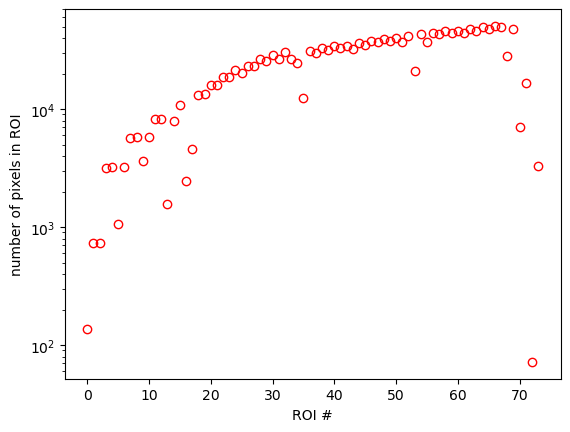

In [82]:
nopr = np.bincount(qind, minlength=(noqs+1))[1:]
roi_x = range(len(nopr))
plt.semilogy(roi_x,nopr,'ro',fillstyle='none');plt.xlabel('ROI #');plt.ylabel('number of pixels in ROI')

## Check one ROI intensity

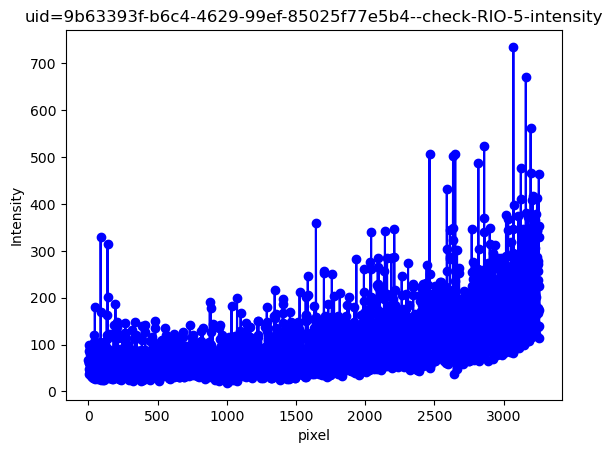

In [83]:
roi_inten = check_ROI_intensity( avg_img, roi_mask, ring_number= 5, uid =uidstr ) #roi starting from 1

## Do a waterfall analysis

In [84]:
qth_interest = 2 #the second ring. #qth_interest starting from 1
if scat_geometry =='saxs' or scat_geometry =='gi_waxs' or scat_geometry == 'gi_saxs':
    if run_waterfall:    
        wat = cal_waterfallc( FD, roi_mask, qindex= qth_interest, save =True, path=data_dir, uid=uidstr)
        plot_waterfallc( wat, qth_interest, aspect= None, vmin=1e-1, vmax= wat.max(), uid=uidstr, save =True, 
                        path=data_dir, beg= FD.beg, cmap = cmap_vge )
 

Get ROI intensity of each frame: 100%|██████████| 500/500 [00:03<00:00, 145.05it/s]


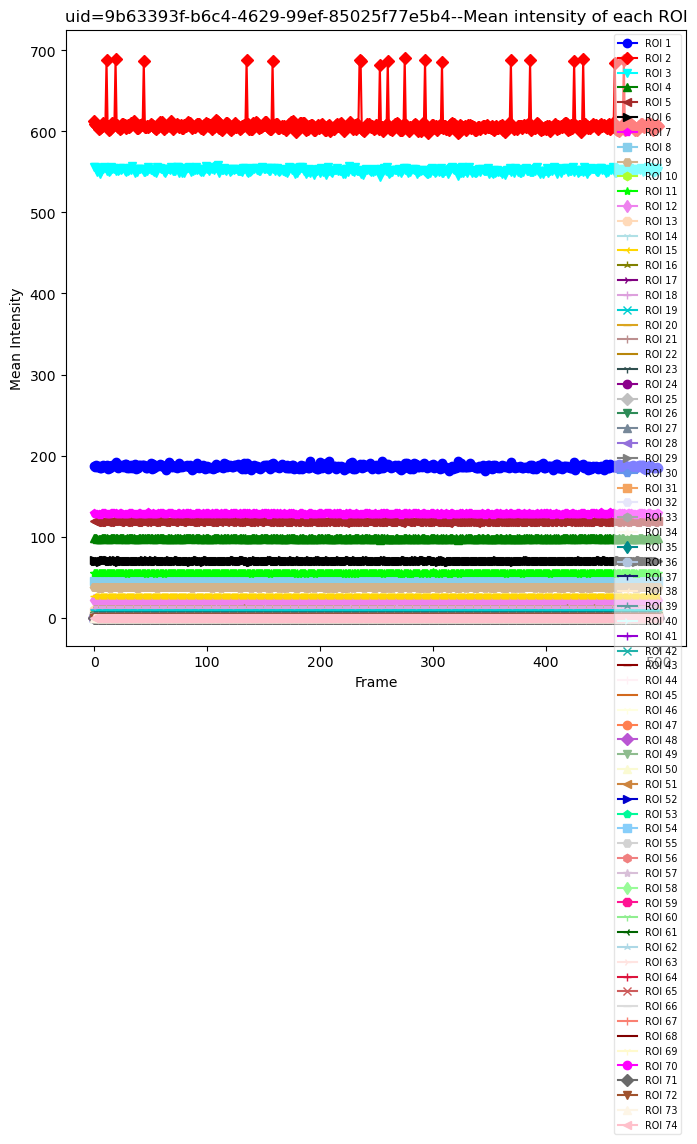

In [85]:
ring_avg = None    
if run_t_ROI_Inten:
    times_roi, mean_int_sets = cal_each_ring_mean_intensityc(FD, roi_mask, timeperframe = None, multi_cor= False )
    mean_int_setsF = np.zeros( [FD.end, mean_int_sets.shape[1] ] )
    mean_int_setsF[FD.beg:FD.end] =mean_int_sets
    plot_each_ring_mean_intensityc( times_roi, mean_int_sets,  uid = uidstr, save=True, path=data_dir )
    roi_avg = np.average( mean_int_sets, axis=0)

## Analysis for mass center of reflective beam center

In [86]:
if run_get_mass_center:
    cx, cy = get_mass_center_one_roi(FD, roi_mask, roi_ind=25)
    fig,ax=plt.subplots(2)
    plot1D( cx, m='o', c='b',ax=ax[0], legend='mass center-refl_X', 
           ylim=[940, 960], ylabel='posX (pixel)')
    plot1D( cy, m='s', c='r',ax=ax[1], legend='mass center-refl_Y', 
           ylim=[1540, 1544], xlabel='frames',ylabel='posY (pixel)')

## One time Correlation

Note : Enter the number of buffers for Muliti tau one time correlation
number of buffers has to be even. More details in https://github.com/scikit-beam/scikit-beam/blob/master/skbeam/core/correlation.py

### if define another good_series

In [87]:
good_start_g2 = FD.beg
good_end_g2 = FD.end
define_good_series = False
hdf5_name_extension=''
if 'rstop' in locals() or 'rstart' in locals():
    define_good_series = True
if define_good_series:
    if 'rstart' in locals():
        good_start_g2 = rstart
    if 'rstop' in locals():
        good_end_g2 = rstop
    hdf5_name_extension = '_%s_%s'%(good_start_g2,good_end_g2)
    FD = Multifile(filename, beg = good_start_g2, end = good_end_g2) #end=1000)
    uid_ = uidstr + '_fra_%s_%s'%(FD.beg, FD.end)
    print( uid_ )

In [88]:
if use_sqnorm:#for transmision SAXS
    norm = get_pixelist_interp_iq( qp_saxs, iq_saxs, roi_mask, setup_pargs['center'])
    print('Using circular average in the normalization of G2 for SAXS scattering.')
elif use_SG:#for Gi-SAXS or WAXS
    avg_imgf = sgolay2d( avg_img, window_size= 11, order= 5) * mask
    norm=np.ravel(avg_imgf)[pixelist]    
    print('Using smoothed image by SavitzkyGolay filter in the normalization of G2.')      
elif use_SG_bin_frames:#for Gi-SAXS or WAXS
    avg_imgf = sgolay2d( avg_img, window_size= 11, order= 5) * mask
    norm_avg=np.ravel(avg_imgf)[pixelist]    
    #print('Using smoothed image by SavitzkyGolay filter in the normalization of G2.')
    bins_number = 1 
    norm = get_SG_norm( FD, pixelist, bins=bins_number, mask=mask, window_size= 11, order=5 )   
    print('Using smoothed bined: %s frames  by SavitzkyGolay filter in the normalization of G2.'%bins_number)     
else:     
    norm= None
    print('Using simple (average) normalization of G2.')      

if use_imgsum_norm:
    imgsum_ = imgsum
    print('Using frame total intensity for intensity normalization in g2 calculation.')      
else:
    imgsum_ = None    
import time

Using circular average in the normalization of G2 for SAXS scattering.
Using frame total intensity for intensity normalization in g2 calculation.


In [89]:
if run_one_time: 
    t0 = time.time()     
    if cal_g2_error:          
        g2,lag_steps,g2_err = cal_g2p(FD,roi_mask,bad_frame_list,good_start, num_buf = 8,
                            num_lev= None,imgsum= imgsum_, norm=norm, cal_error= True )
    else:   
        g2,lag_steps    =     cal_g2p(FD,roi_mask,bad_frame_list,good_start, num_buf = 8,
                            num_lev= None,imgsum= imgsum_, norm=norm, cal_error= False )

    run_time(t0)
    

In this g2 calculation, the buf and lev number are: 8--8--
500 frames will be processed...
Starting assign the tasks...


100%|██████████| 74/74 [00:01<00:00, 41.64it/s]


Starting running the tasks...


100%|██████████| 74/74 [00:10<00:00,  6.88it/s]

G2 calculation DONE!
Total time: 16.360 sec


In [90]:
if run_one_time:
    
    taus = lag_steps * timeperframe         
    try:
        g2_pds = save_g2_general( g2, taus=taus,qr= np.array( list( qval_dict.values() ) )[:g2.shape[1],0],
                                            qz = np.array( list( qval_dict.values() ) )[:g2.shape[1],1],
                             uid=uid_+'_g2.csv', path= data_dir, return_res=True )
    except:
        g2_pds = save_g2_general( g2, taus=taus,qr= np.array( list( qval_dict.values() ) )[:g2.shape[1],0],                                             
                             uid=uid_+'_'+q_mask_name+'_g2.csv', path= data_dir, return_res=True )   
    if cal_g2_error:    
        try:
            g2_err_pds = save_g2_general( g2_err, taus=taus,qr= np.array( list( qval_dict.values() ) )[:g2.shape[1],0],
                                                qz = np.array( list( qval_dict.values() ) )[:g2.shape[1],1],
                                 uid=uid_+'_g2_err.csv', path= data_dir, return_res=True )
        except:
            g2_err_pds = save_g2_general( g2_err, taus=taus,qr= np.array( list( qval_dict.values() ) )[:g2.shape[1],0],                                             
                                 uid=uid_+'_'+q_mask_name+'_g2_err.csv', path= data_dir, return_res=True )         
    

The correlation function is saved in /nsls2/data/chx/proposals/2025-1/pass-315366/Results/9b63393f-b6c4-4629-99ef-85025f77e5b4/ with filename as uid=9b63393f-b6c4-4629-99ef-85025f77e5b4_fra_0_500_g2.csv


# Fit g2

In [91]:
if run_one_time:
    try:
        g2_fit_result, taus_fit, g2_fit = get_g2_fit_general( g2,  taus, 
                    function = fit_g2_func,  vlim=[0.95, 1.05], fit_range= None,  
                fit_variables={'baseline':False, 'beta': True, 'alpha':True,'relaxation_rate':True,},                                  
                guess_values={'baseline':1.0,'beta': 0.2,'alpha':1.0,'relaxation_rate':1e-3},
                guess_limits = dict( baseline =[.9, 2], alpha=[0, 2],
                            beta = [0.01, 0.4], relaxation_rate= [1e-7, 1e7]) ,) 
        g2_fit_paras = save_g2_fit_para_tocsv(g2_fit_result,  filename= uid_ +'_'+q_mask_name +'_g2_fit_paras.csv', path=data_dir ) 
        g2_fit_failed = False
    except:
        g2_fit_failed = True
        from pandas import DataFrame # need to make up a fit result, otherwise writing the pdf report becomes difficult
        g2_fit_paras=DataFrame(np.zeros([np.shape(g2)[1],4]),columns=['beta','relaxation_rate','alpha','baseline'])

The g2 fitting parameters are saved in /nsls2/data/chx/proposals/2025-1/pass-315366/Results/9b63393f-b6c4-4629-99ef-85025f77e5b4/uid=9b63393f-b6c4-4629-99ef-85025f77e5b4_fra_0_500_phi_4x_20deg_g2_fit_paras.csv


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


The combined image is saved as: /nsls2/data/chx/proposals/2025-1/pass-315366/Results/9b63393f-b6c4-4629-99ef-85025f77e5b4/uid=9b63393f-b6c4-4629-99ef-85025f77e5b4_fra_0_500_g2_fit__joint.png


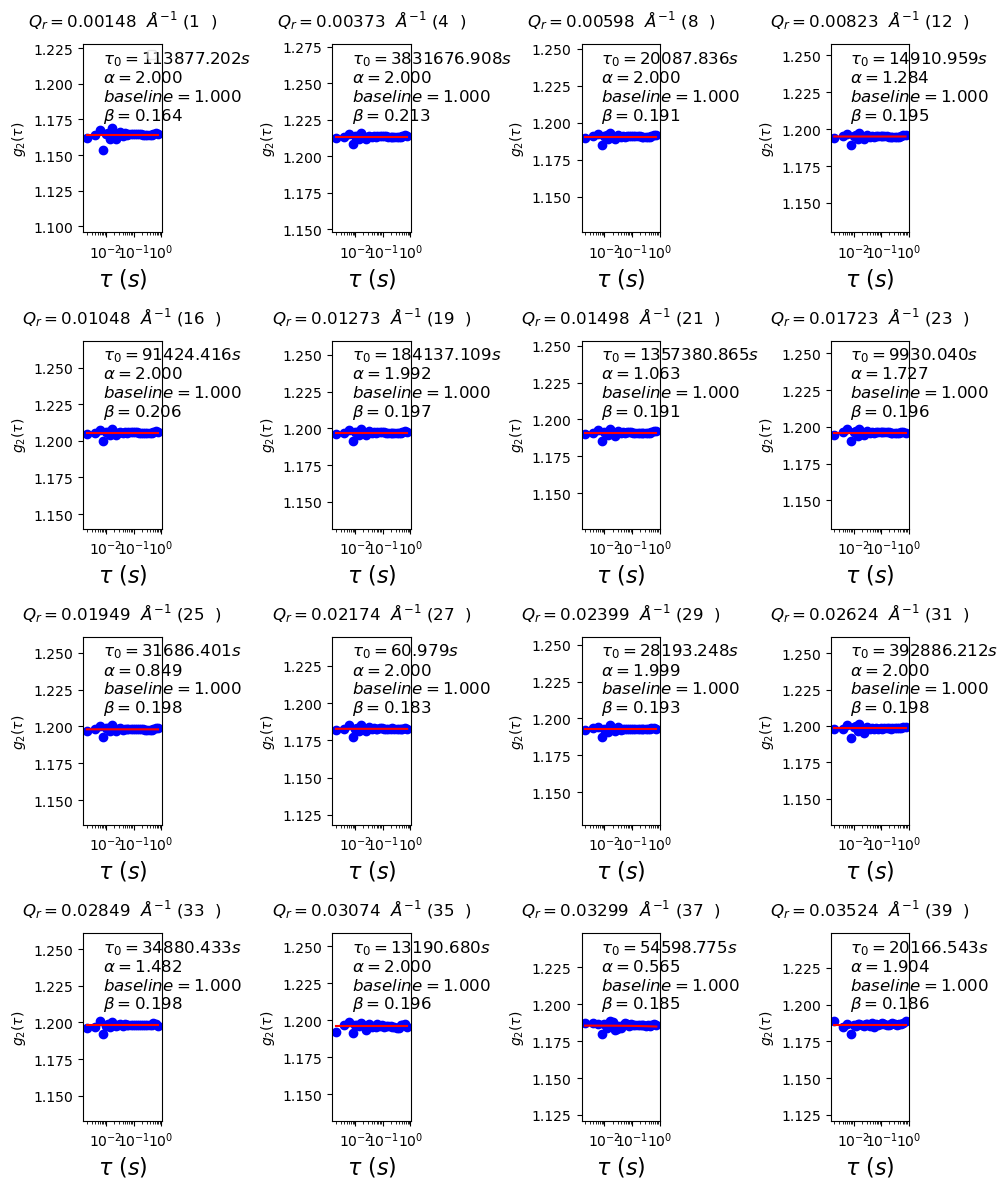

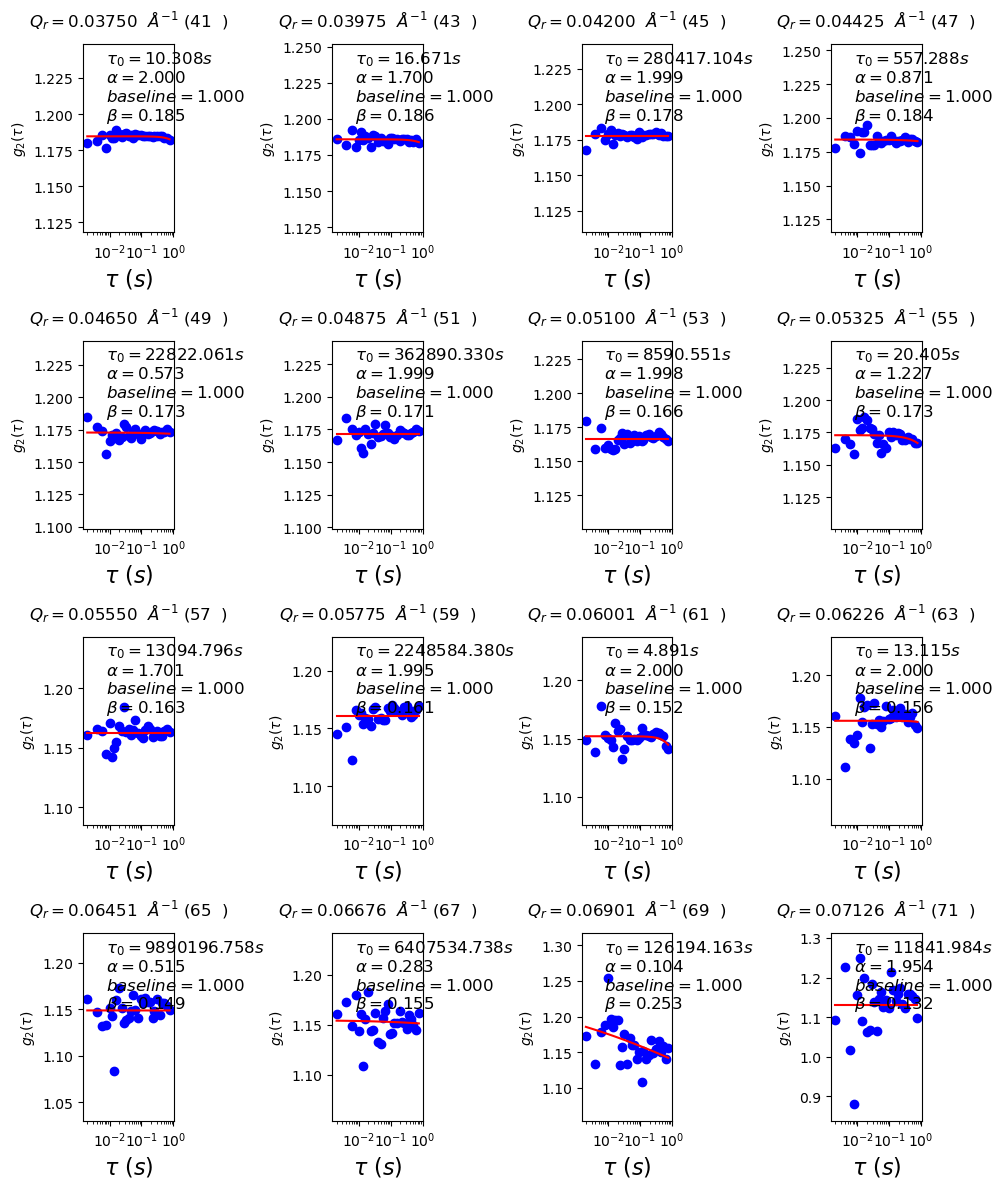

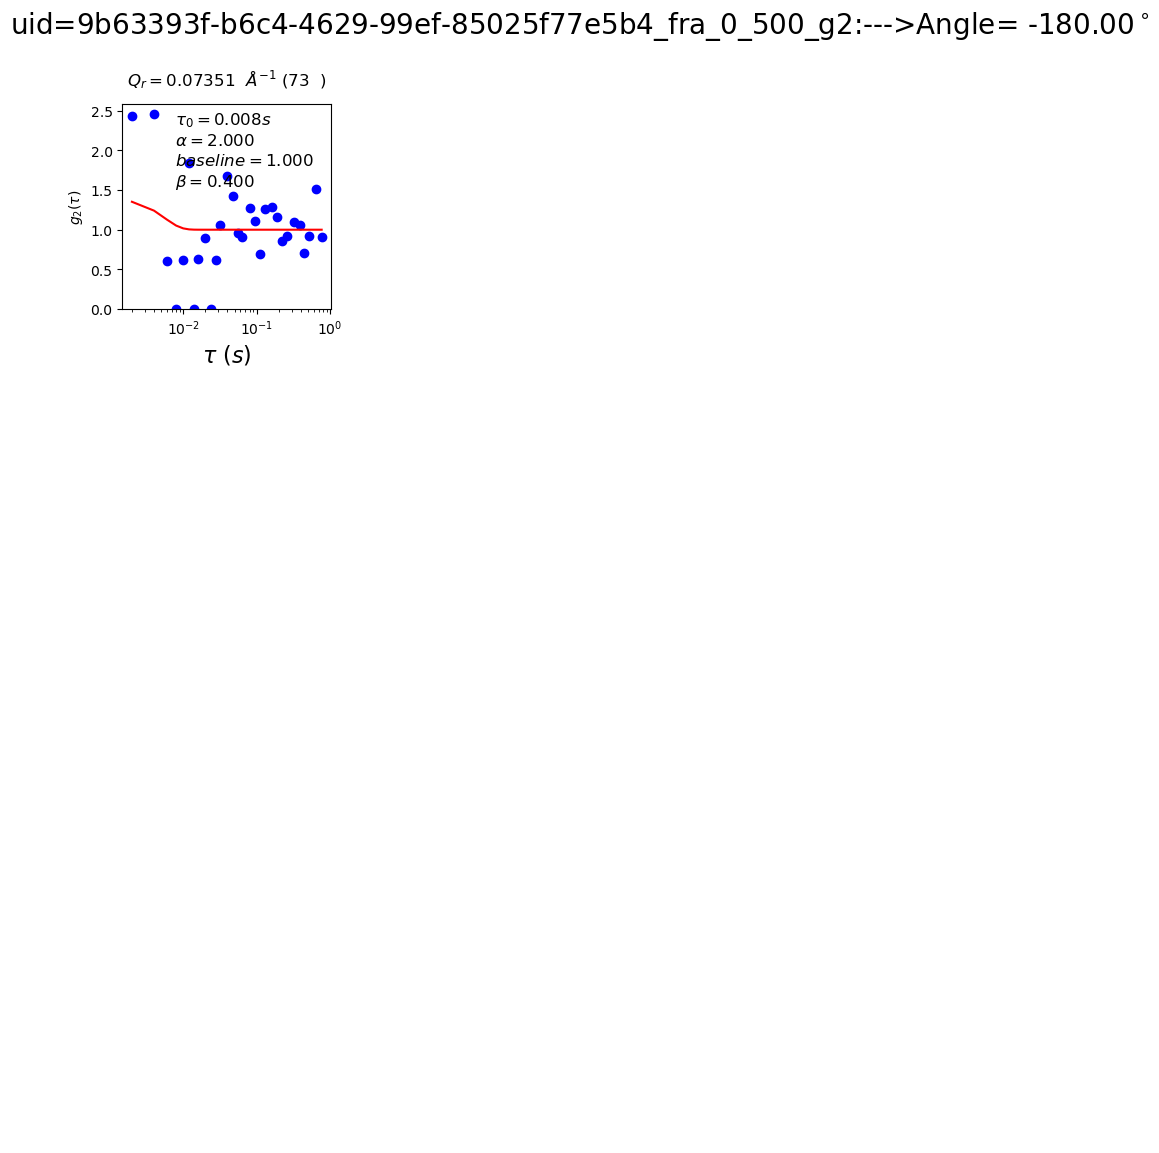

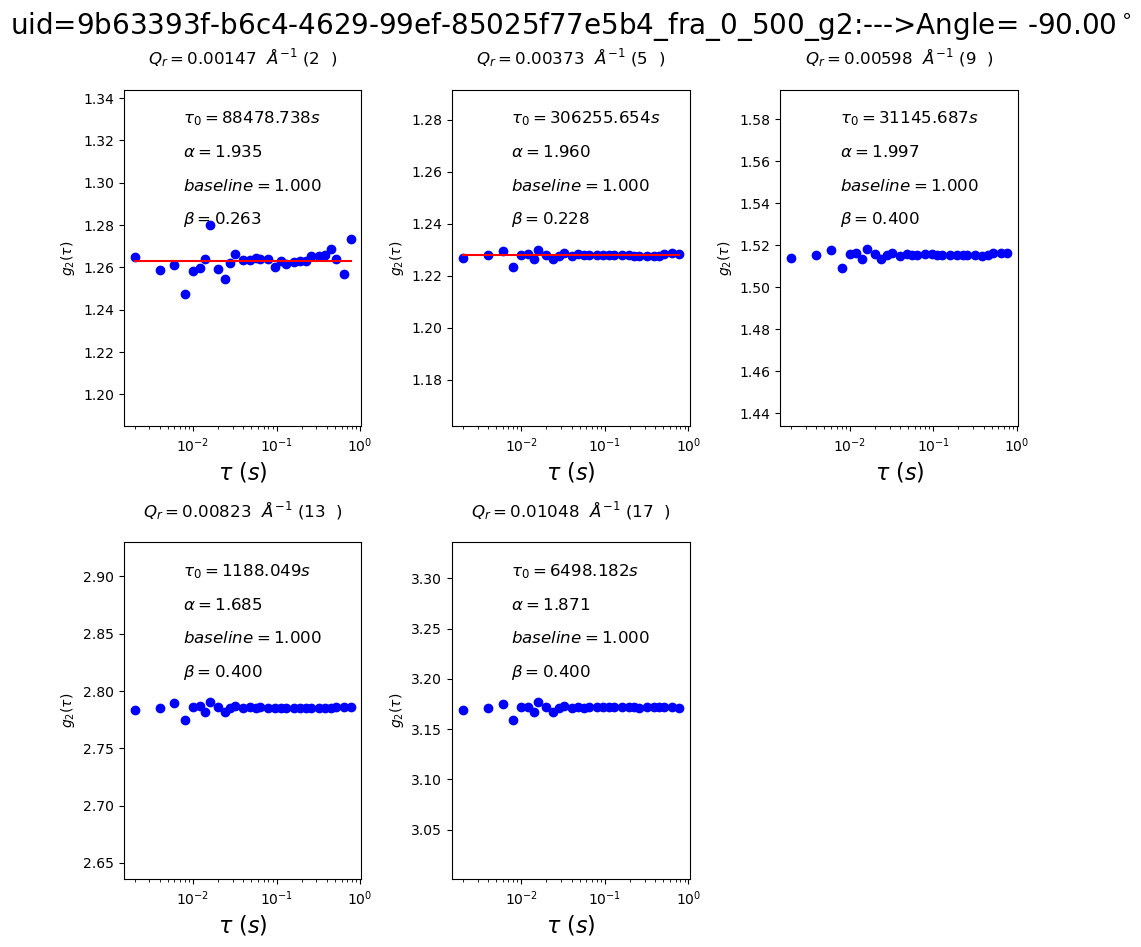

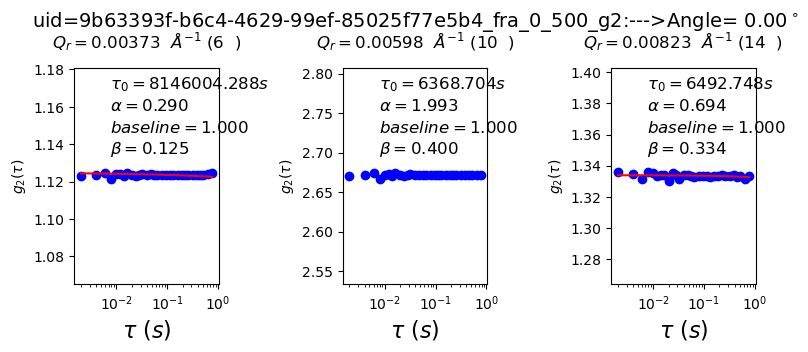

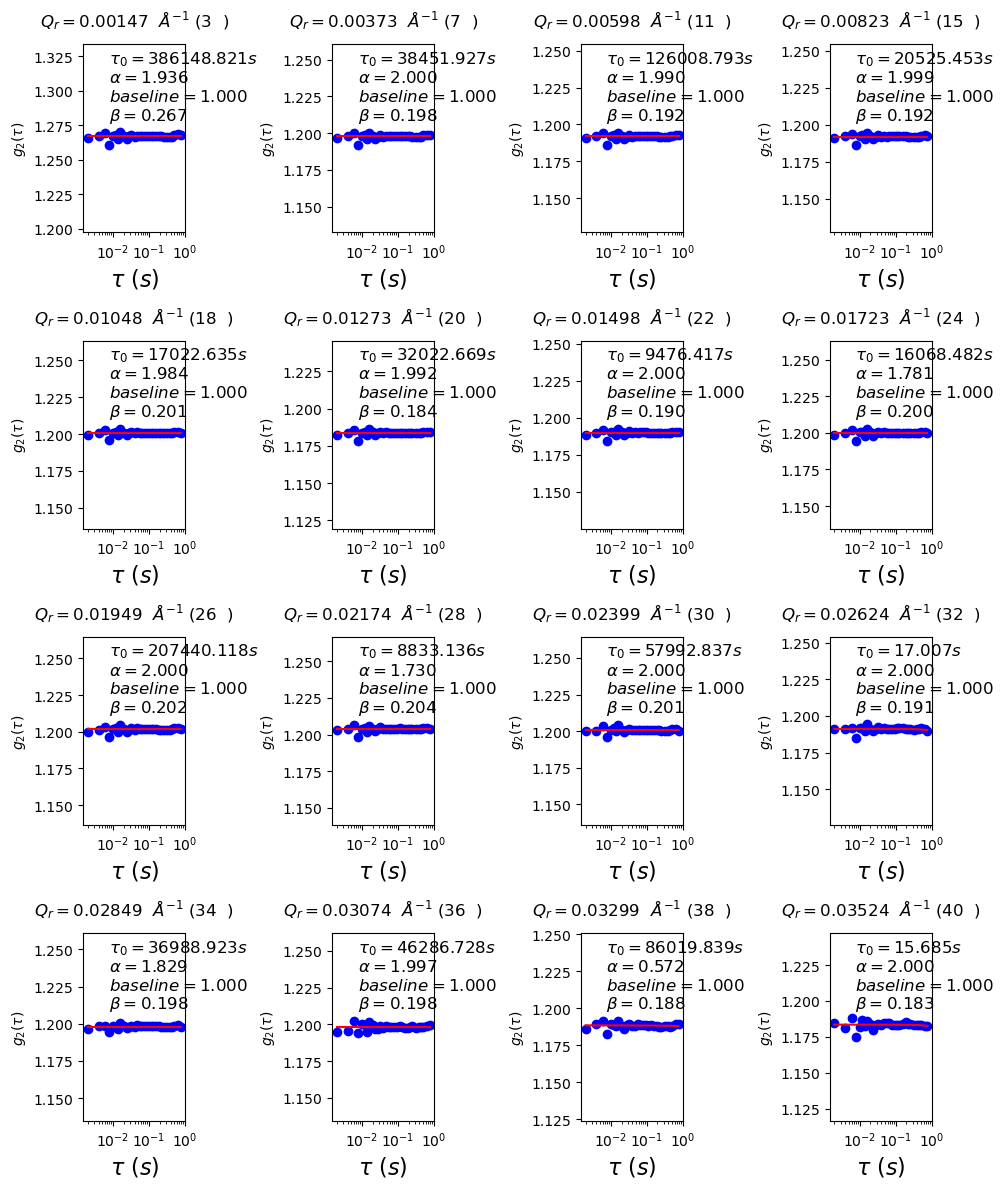

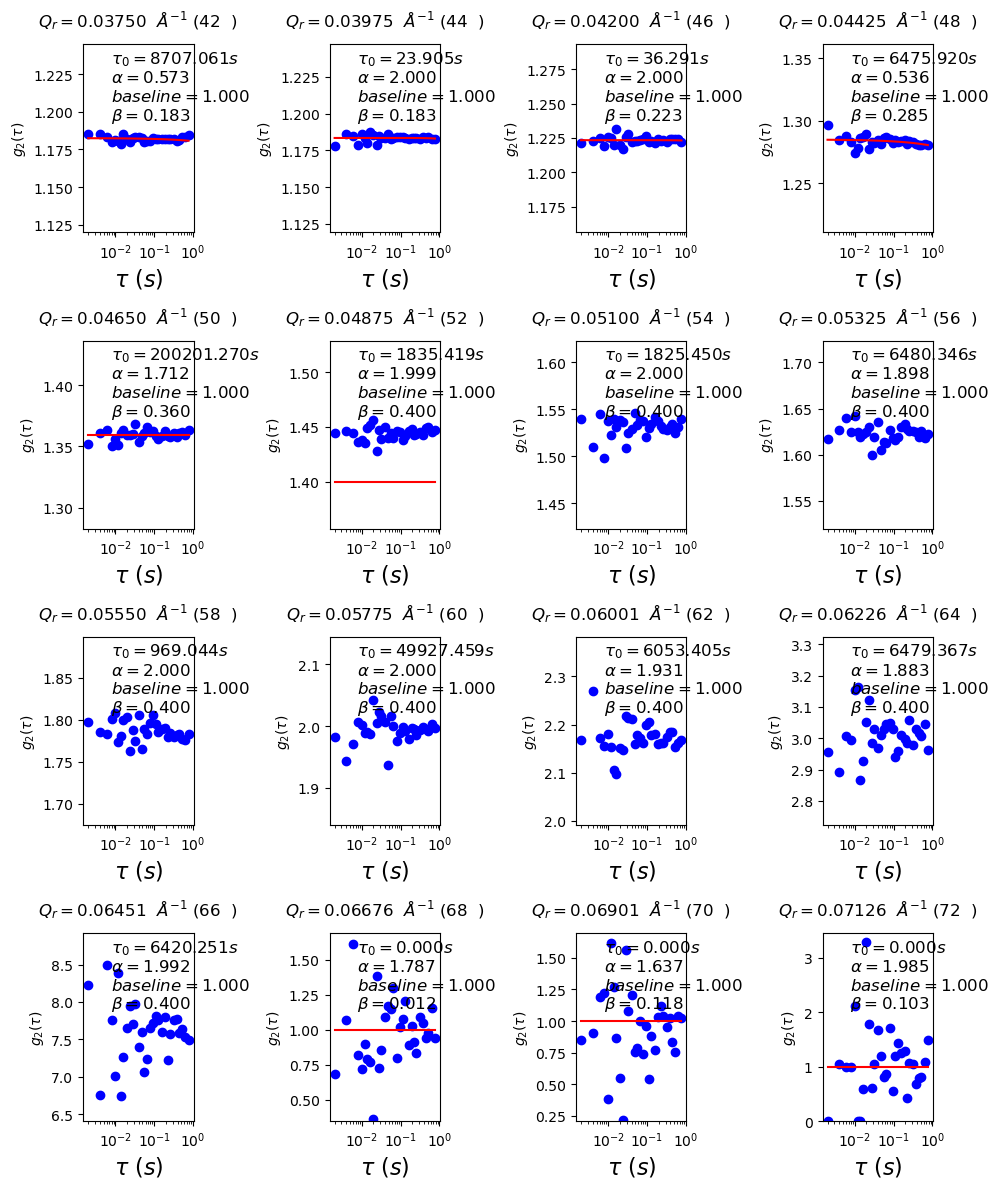

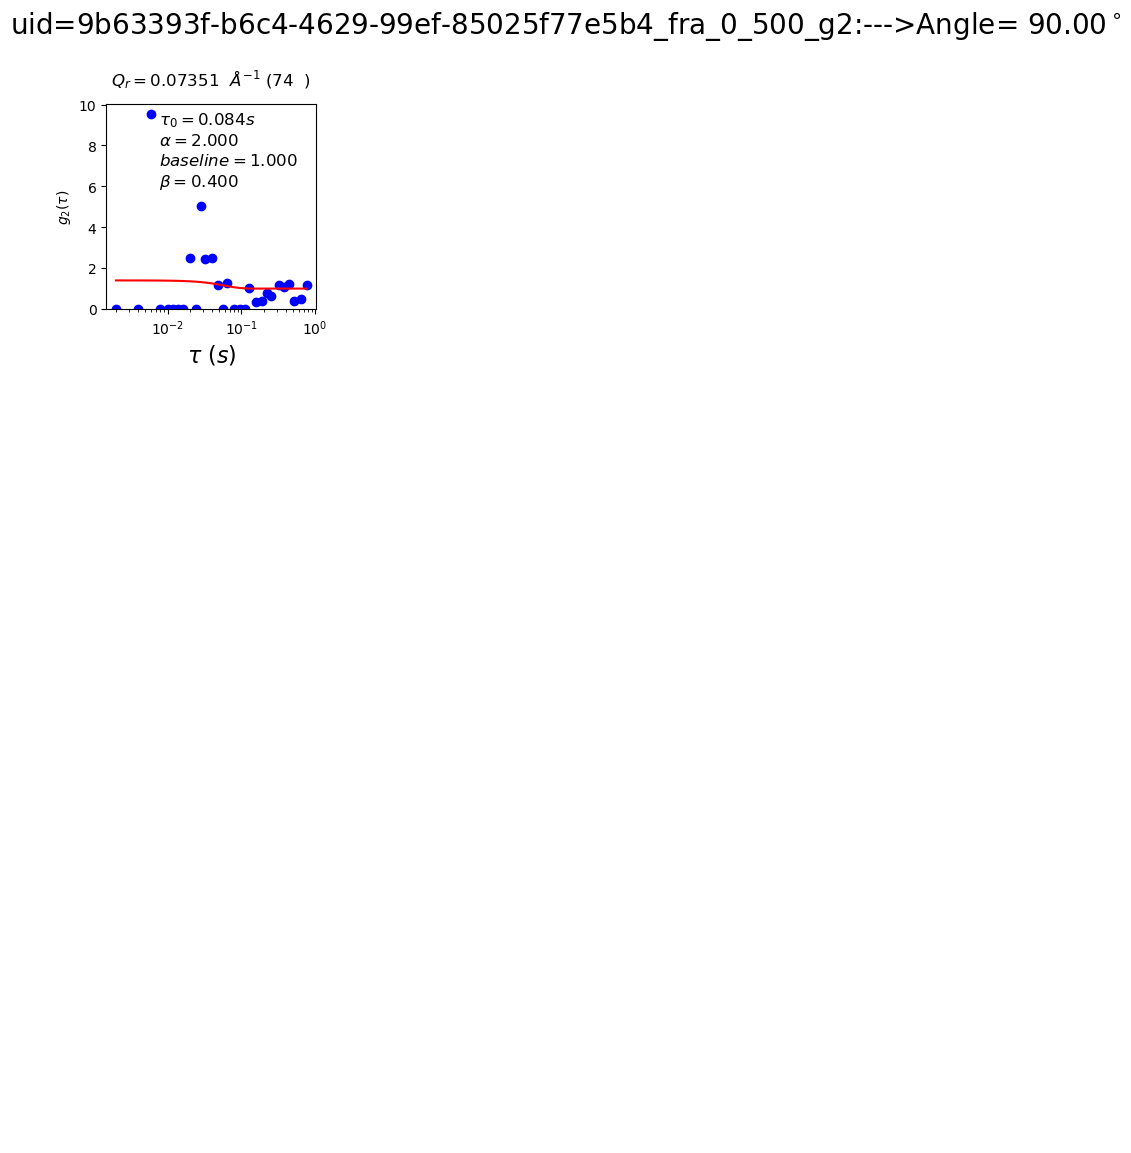

In [92]:
if run_one_time:
    if cal_g2_error:
        g2_fit_err = np.zeros_like(g2_fit)
        if not g2_fit_failed:
            
            plot_g2_general( g2_dict={1:g2, 2:g2_fit}, taus_dict={1:taus, 2:taus_fit},
                    vlim=[0.95, 1.05], g2_err_dict= {1:g2_err, 2: g2_fit_err},
                    qval_dict = dict(itertools.islice(qval_dict.items(),g2.shape[1])), fit_res= g2_fit_result,  geometry= scat_geometry_,filename= uid_+'_g2', 
                    path= data_dir, function= fit_g2_func,  ylabel='g2', append_name=  '_fit',
                           qpi_analysis=True)
        else:
            plot_g2_general(g2_dict={1:g2, }, taus_dict={1:taus,},
                    vlim=[0.95, 1.05], g2_err_dict= {1:g2_err},
                    qval_dict = dict(itertools.islice(qval_dict.items(),g2.shape[1])),
                        fit_res= None,  geometry= scat_geometry_,filename= uid_+'_g2', 
                    path= data_dir, function= fit_g2_func,  ylabel='g2', append_name=  '',
                           qpi_analysis=True)
            
    else:    
        if not g2_fit_failed:
            plot_g2_general( g2_dict={1:g2, 2:g2_fit}, taus_dict={1:taus, 2:taus_fit}, vlim=[0.95, 1.05],
                qval_dict = dict(itertools.islice(qval_dict.items(),g2.shape[1])), fit_res= g2_fit_result,  geometry= scat_geometry_,filename= uid_+'_g2', 
                path= data_dir, function= fit_g2_func,  ylabel='g2', append_name=  '_fit',
                           qpi_analysis=True)
        else:    
            plot_g2_general( g2_dict={1:g2}, taus_dict={1:taus}, vlim=[0.95, 1.05],
                qval_dict = dict(itertools.islice(qval_dict.items(),g2.shape[1])), fit_res= None,  geometry= scat_geometry_,filename= uid_+'_g2', 
                path= data_dir, function= fit_g2_func,  ylabel='g2', append_name=  '',
                           qpi_analysis=True)    


The fitted diffusion coefficient D0 is:  8.575e-10   A^2S-1
The fitted diffusion coefficient D0 is:  2.710e-10   A^2S-1
The fitted diffusion coefficient D0 is:  3.129e-11   A^2S-1


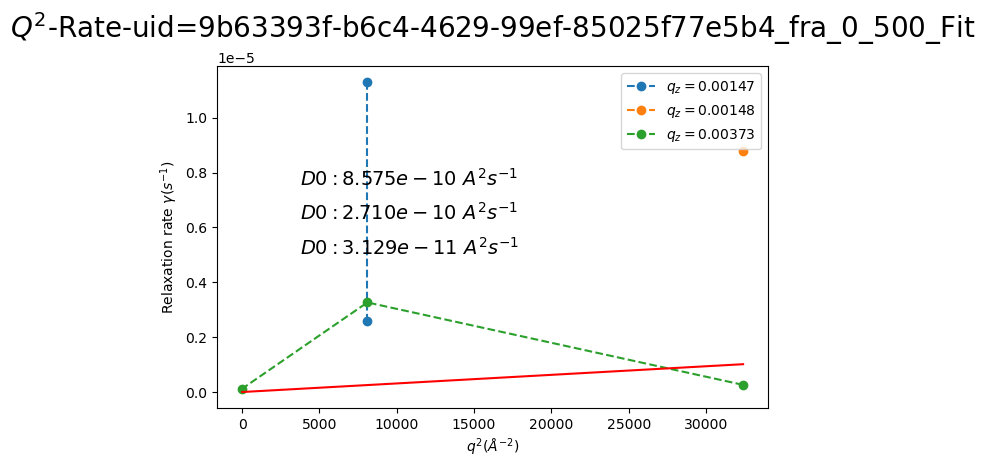

In [117]:
if run_one_time:
    try:
        if True:
            fs, fe = 0, 6
            #fs,fe=0, 6
            qval_dict_ = {k:qval_dict[k] for k in list(qval_dict.keys())[fs:fe]  }
            D0, qrate_fit_res = get_q_rate_fit_general(  qval_dict_, g2_fit_paras['relaxation_rate'][fs:fe], 
                                                       geometry=  scat_geometry_ )
            plot_q_rate_fit_general( qval_dict_, g2_fit_paras['relaxation_rate'][fs:fe],  qrate_fit_res, 
                                    geometry= scat_geometry_,uid=uid_  , path= data_dir )
        elif False:
            D0, qrate_fit_res = get_q_rate_fit_general(  qval_dict, g2_fit_paras['relaxation_rate'],
                                        fit_range=[0, 26],   geometry= scat_geometry_ )    
            plot_q_rate_fit_general( qval_dict, g2_fit_paras['relaxation_rate'],  qrate_fit_res,   
                                geometry=  scat_geometry_,uid=uid_  ,
                                    show_fit=False, path= data_dir, plot_all_range=False) 
        else:
            ##plot log_q, log_rate
            plot_q_rate_general( qval_dict, g2_fit_paras['relaxation_rate'],  
                                    geometry= scat_geometry_,uid=uid_  , path= data_dir )

            plot_q_g2fitpara_general( qval_dict, g2_fit_paras,  
                                    geometry= scat_geometry_,uid=uid_  , path= data_dir )
    except:
        pass


In [118]:
if track_progress:
    if settings_dict_['run_one_time']:
        update_prog_dict_run_XPCS_SAXS(prog_dict_file,process_id,progress_key='run_one_time', progress='stop',start_time=None, stop_time=time.time(), verbose=True)
    if settings_dict_['run_two_time']:
        update_prog_dict_run_XPCS_SAXS(prog_dict_file,process_id,progress_key='run_two_time', progress='start',start_time=time.time(), stop_time=None, verbose=True)

# For two-time

In [119]:
define_good_series = True  #making sure that the 2TCF takes ALL data into account -> this should be the default!
if define_good_series:
    good_start = 0
    good_end =md['number of images']
    FD = Multifile(filename, beg = good_start, end = good_end)
    uid_ = uidstr + '_fra_%s_%s'%(FD.beg, FD.end)
    print( uid_ )

uid=9b63393f-b6c4-4629-99ef-85025f77e5b4_fra_0_500


In [120]:
data_pixel = None
if run_two_time:    
    data_pixel =   Get_Pixel_Arrayc( FD, pixelist,  norm= norm,  ).get_data()
    
    ### With another normalizaiton by using roi_intensity for each frame
    #data_pixel =   Get_Pixel_Arrayc( FD, pixelist,  norm= norm,  mean_int_sets = mean_int_setsF,qind=qind ).get_data()

100%|██████████| 500/500 [00:04<00:00, 108.38it/s]


In [121]:
import time
t0=time.time()
g12b=None
if run_two_time:     
    g12b = auto_two_Arrayc(  data_pixel,  roi_mask, index = None   )
    if run_dose:
        np.save( data_dir + 'uid=%s_g12b'%uid, g12b)
run_time( t0 )  

100%|██████████| 74/74 [00:04<00:00, 14.92it/s]

Total time: 5.015 sec


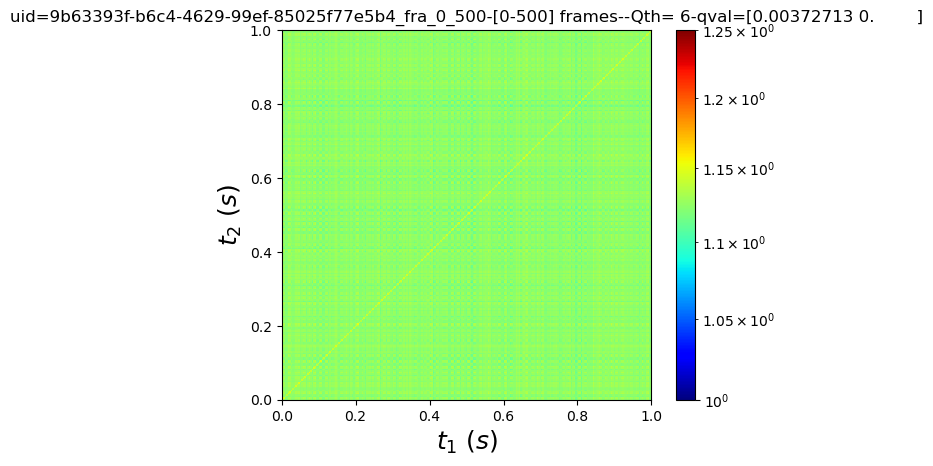

In [122]:
if run_two_time:
    
    show_C12(  np.nan_to_num( g12b ), q_ind= 6, qlabel=dict(itertools.islice(qval_dict.items(),g12b.shape[2])),
             #N1= FD.beg,logs=False, N2=min( FD.end,10000), 
             vmin= 1.00, vmax=1.25,  timeperframe=timeperframe,save=True, 
             path= data_dir, uid = uid_ ,cmap=plt.cm.jet)#cmap=cmap_albula)   
    

In [123]:
multi_tau_steps = True
if run_two_time:
    if lag_steps is None:
        num_bufs=8
        noframes = FD.end - FD.beg
        num_levels = int(np.log( noframes/(num_bufs-1))/np.log(2) +1) +1
        tot_channels, lag_steps, dict_lag = multi_tau_lags(num_levels, num_bufs)
        max_taus= lag_steps.max()
        
    #max_taus= lag_steps.max()  
    max_taus = Nimg    
    t0=time.time()
    #tausb = np.arange( g2b.shape[0])[:max_taus] *timeperframe
    if multi_tau_steps:
        lag_steps_ = lag_steps[   lag_steps <= g12b.shape[0] ]
        g2b = get_one_time_from_two_time(g12b)[lag_steps_]
        tausb = lag_steps_ *timeperframe
    else:
        tausb = (np.arange( g12b.shape[0]) *timeperframe)[:-200]
        g2b = (get_one_time_from_two_time(g12b))[:-200]
    run_time(t0)
         
    g2b_pds = save_g2_general( g2b, taus=tausb, qr= np.array( list( qval_dict.values() ) )[:g2.shape[1],0],
                              qz=None, uid=uid_+'_'+q_mask_name+'_g2b.csv', path= data_dir, return_res=True )
    

Total time: 0.026 sec
The correlation function is saved in /nsls2/data/chx/proposals/2025-1/pass-315366/Results/9b63393f-b6c4-4629-99ef-85025f77e5b4/ with filename as uid=9b63393f-b6c4-4629-99ef-85025f77e5b4_fra_0_500_phi_4x_20deg_g2b.csv


In [124]:
if run_two_time:    
    try: 
        g2b_fit_result, tausb_fit, g2b_fit = get_g2_fit_general( g2b,  tausb, 
                function = fit_g2_func,  vlim=[0.95, 1.05], fit_range= None,  
            fit_variables={'baseline':False, 'beta': True, 'alpha':True,'relaxation_rate':True},                                  
            guess_values={'baseline':1.0,'beta': 0.15,'alpha':1.0,'relaxation_rate':1e-3,},
            guess_limits = dict( baseline =[1, 1.8], alpha=[0, 2],
                        beta = [0, 1], relaxation_rate= [1e-8, 5000]) ) 
        g2b_fit_paras = save_g2_fit_para_tocsv(g2b_fit_result,  filename= uid_  +'_'+q_mask_name+'_g2b_fit_paras.csv', path=data_dir )
        g2b_fit_failed = False
    except:
        g2b_fit_failed = True
        g2b_fit_paras = g2_fit_paras * 0


The g2 fitting parameters are saved in /nsls2/data/chx/proposals/2025-1/pass-315366/Results/9b63393f-b6c4-4629-99ef-85025f77e5b4/uid=9b63393f-b6c4-4629-99ef-85025f77e5b4_fra_0_500_phi_4x_20deg_g2b_fit_paras.csv


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


The combined image is saved as: /nsls2/data/chx/proposals/2025-1/pass-315366/Results/9b63393f-b6c4-4629-99ef-85025f77e5b4/uid=9b63393f-b6c4-4629-99ef-85025f77e5b4_fra_0_500_g2_b_fit__joint.png


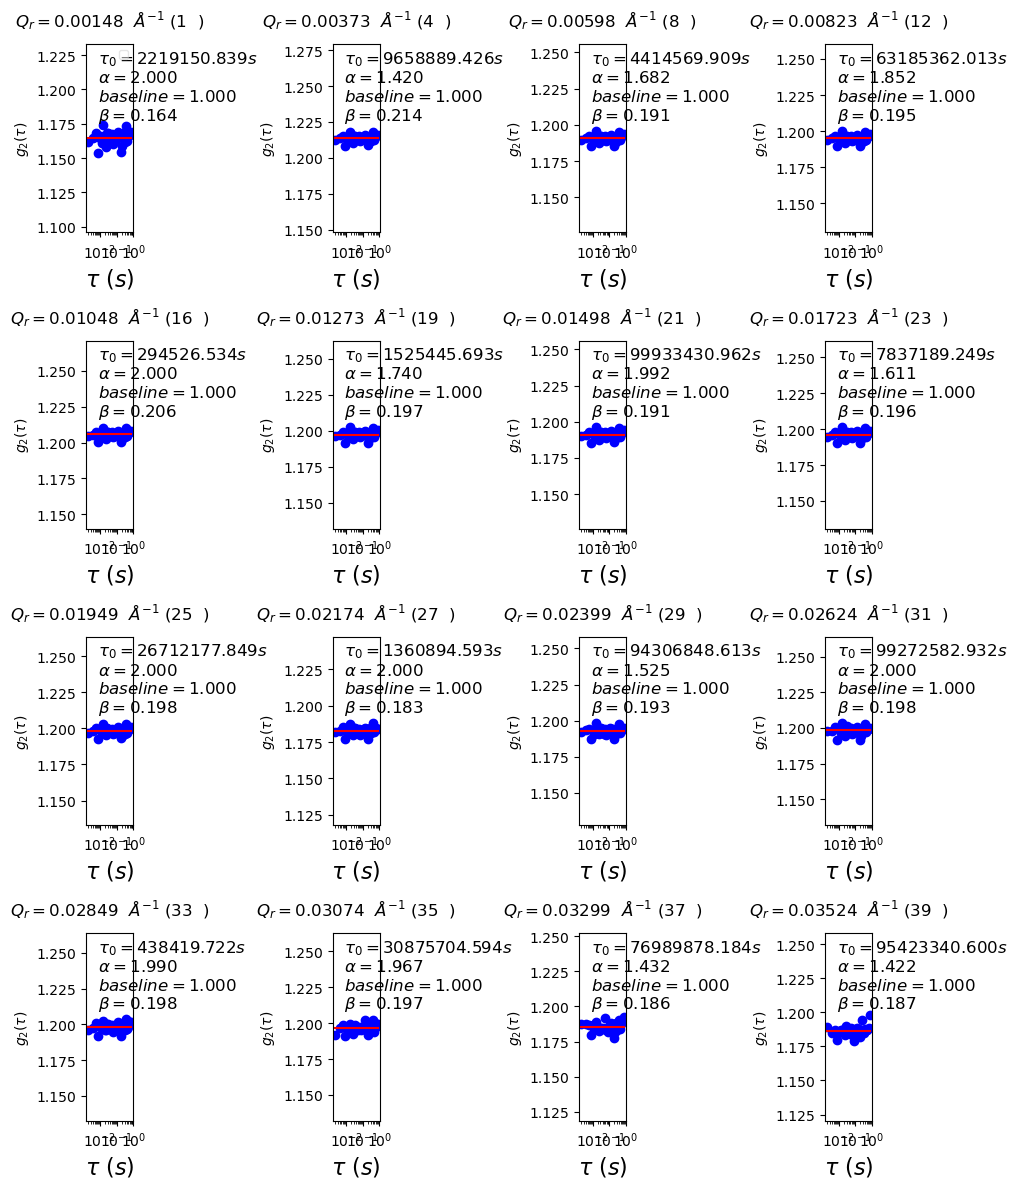

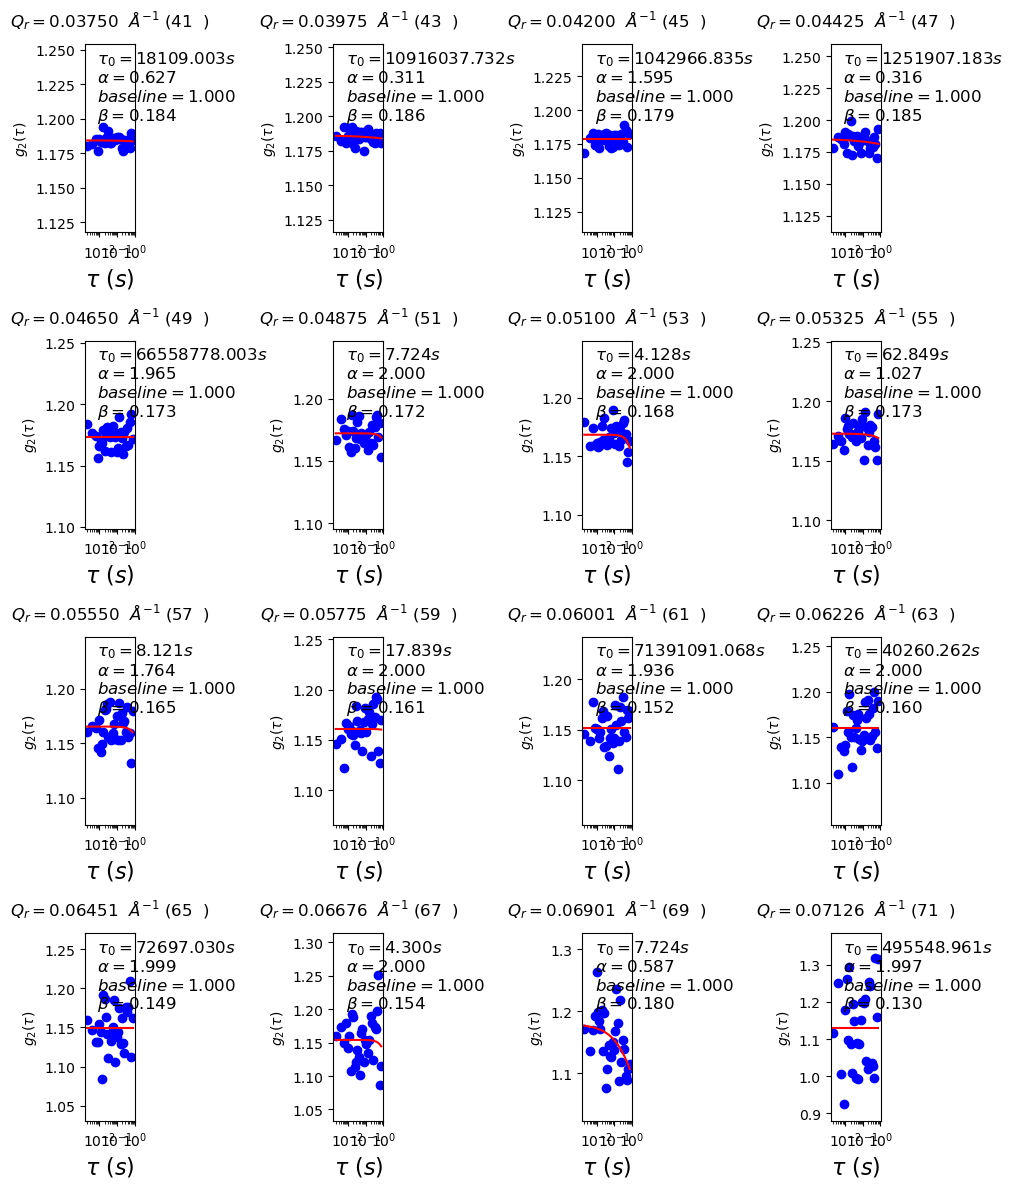

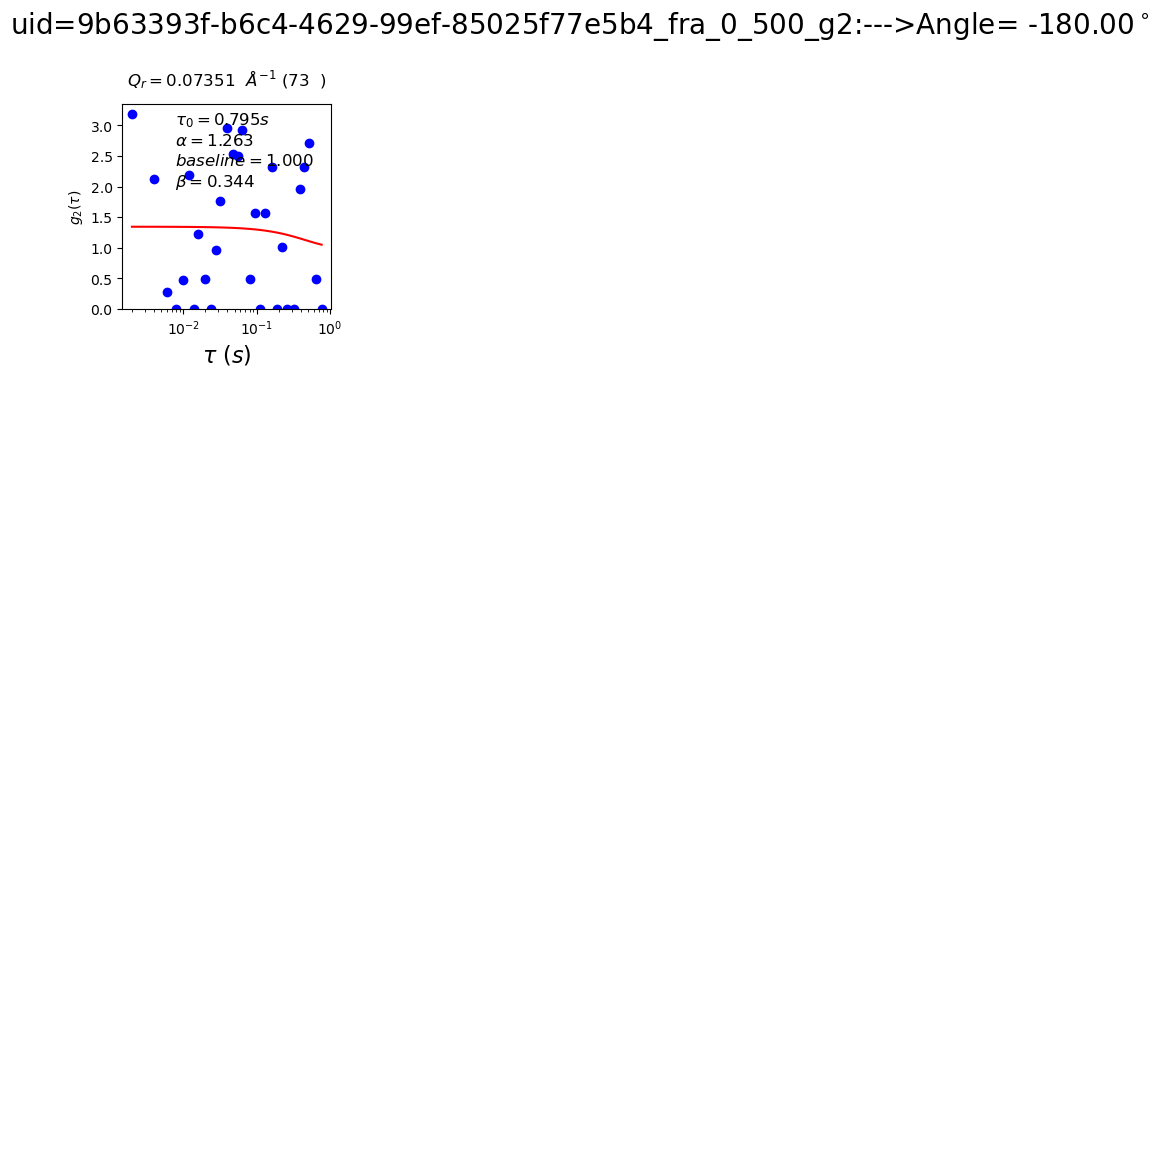

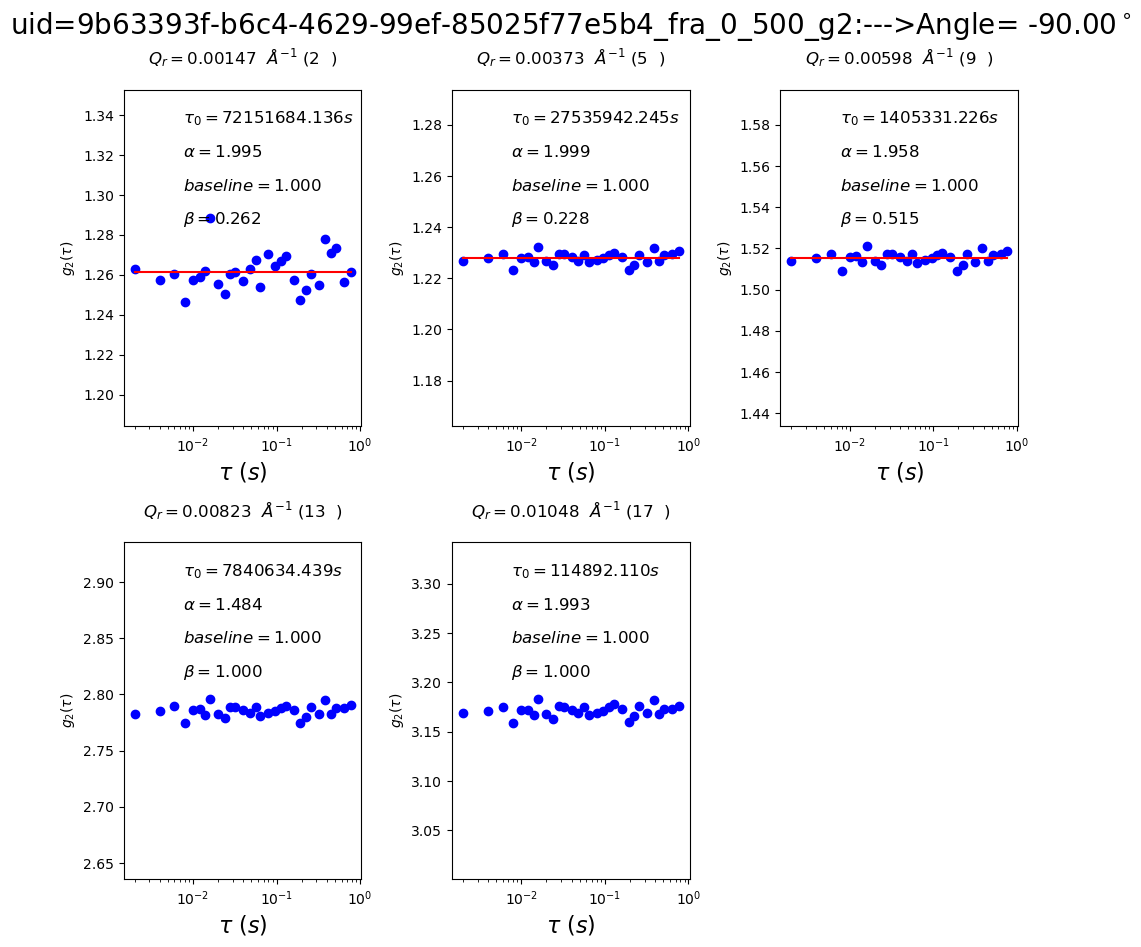

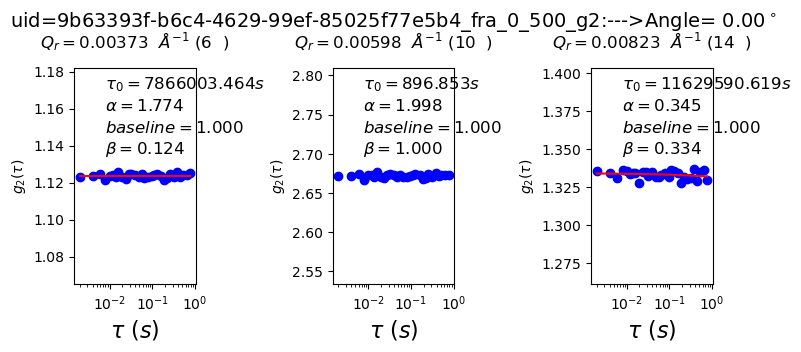

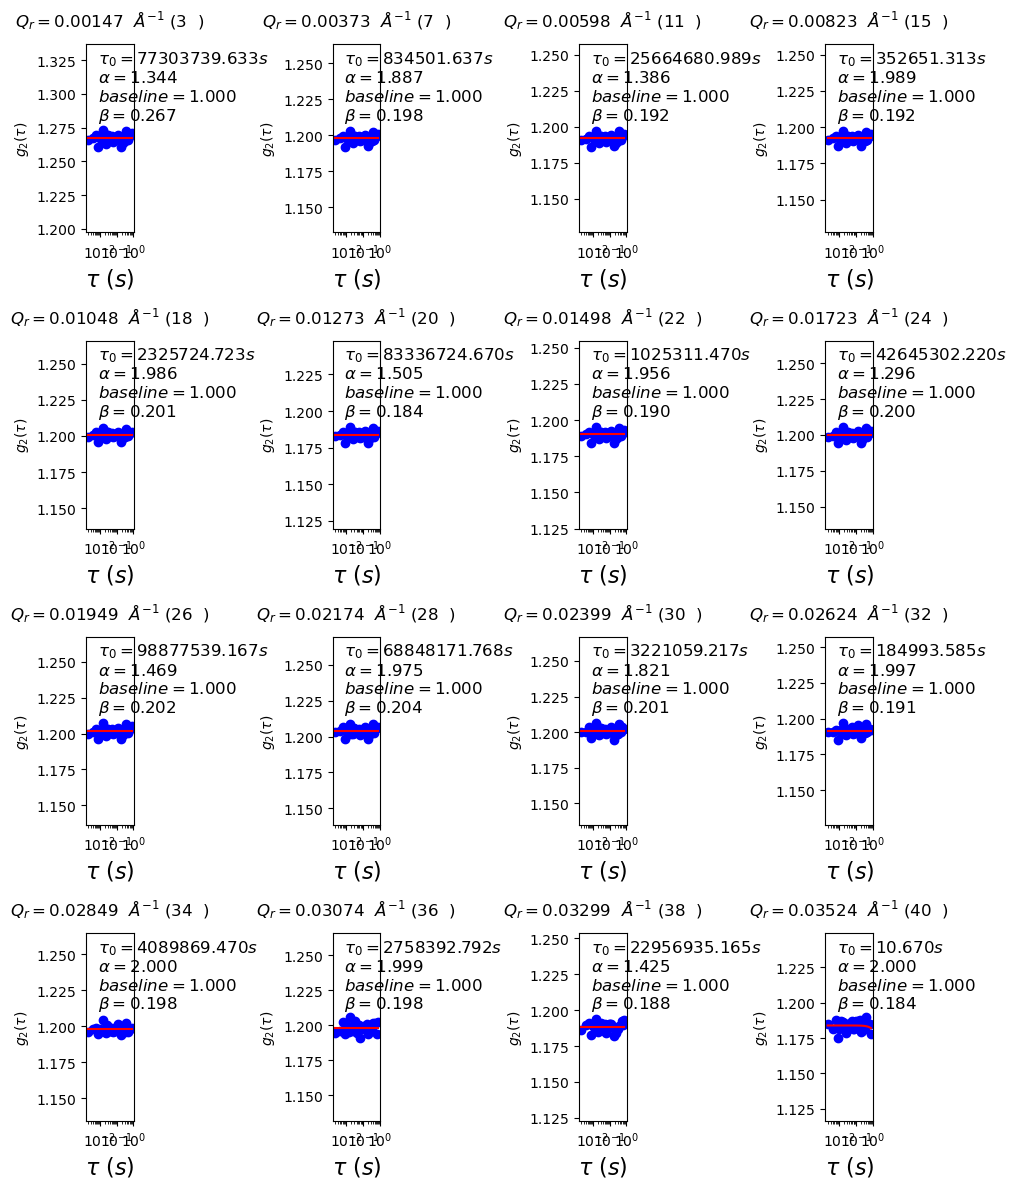

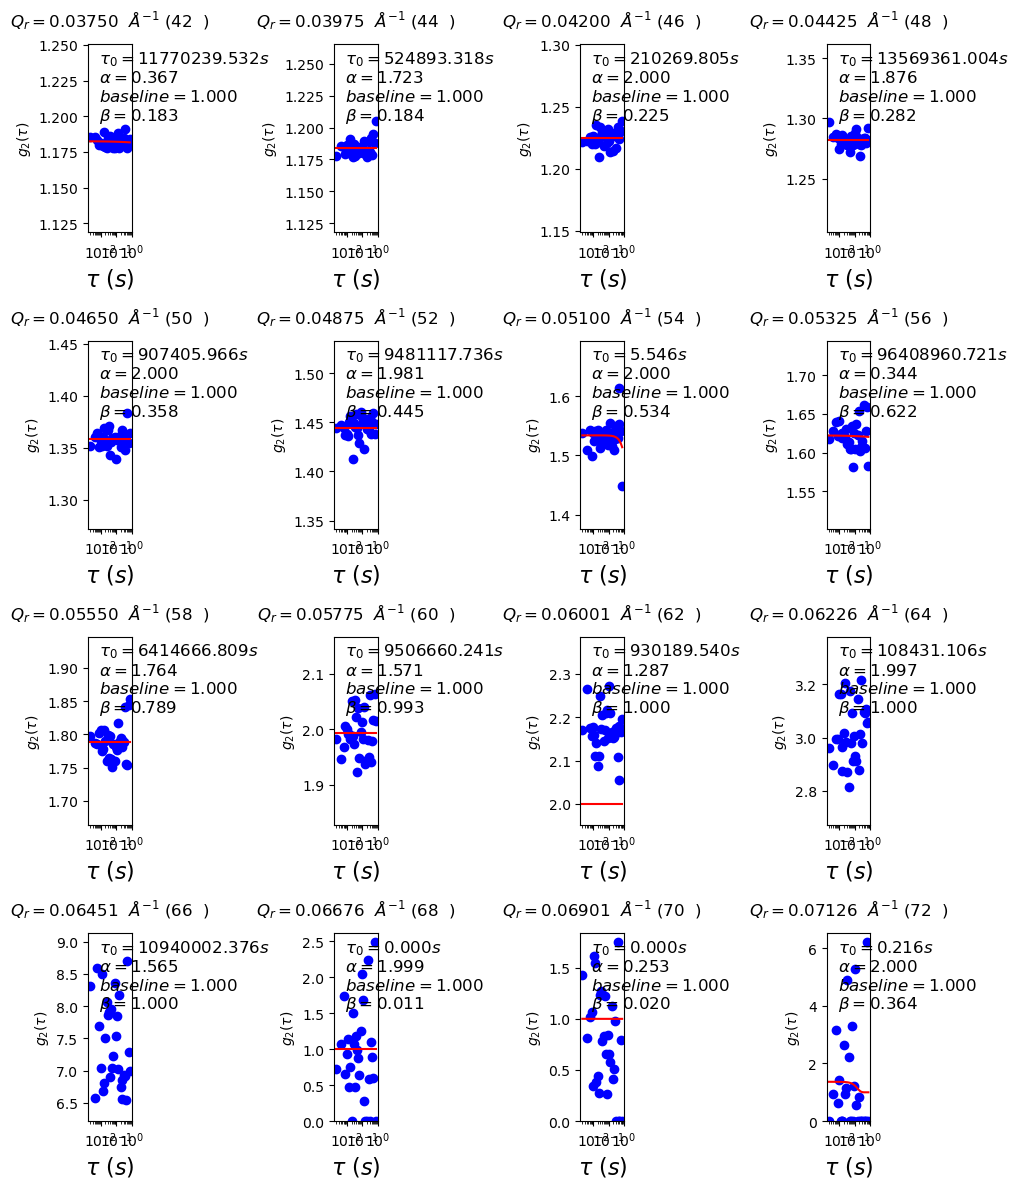

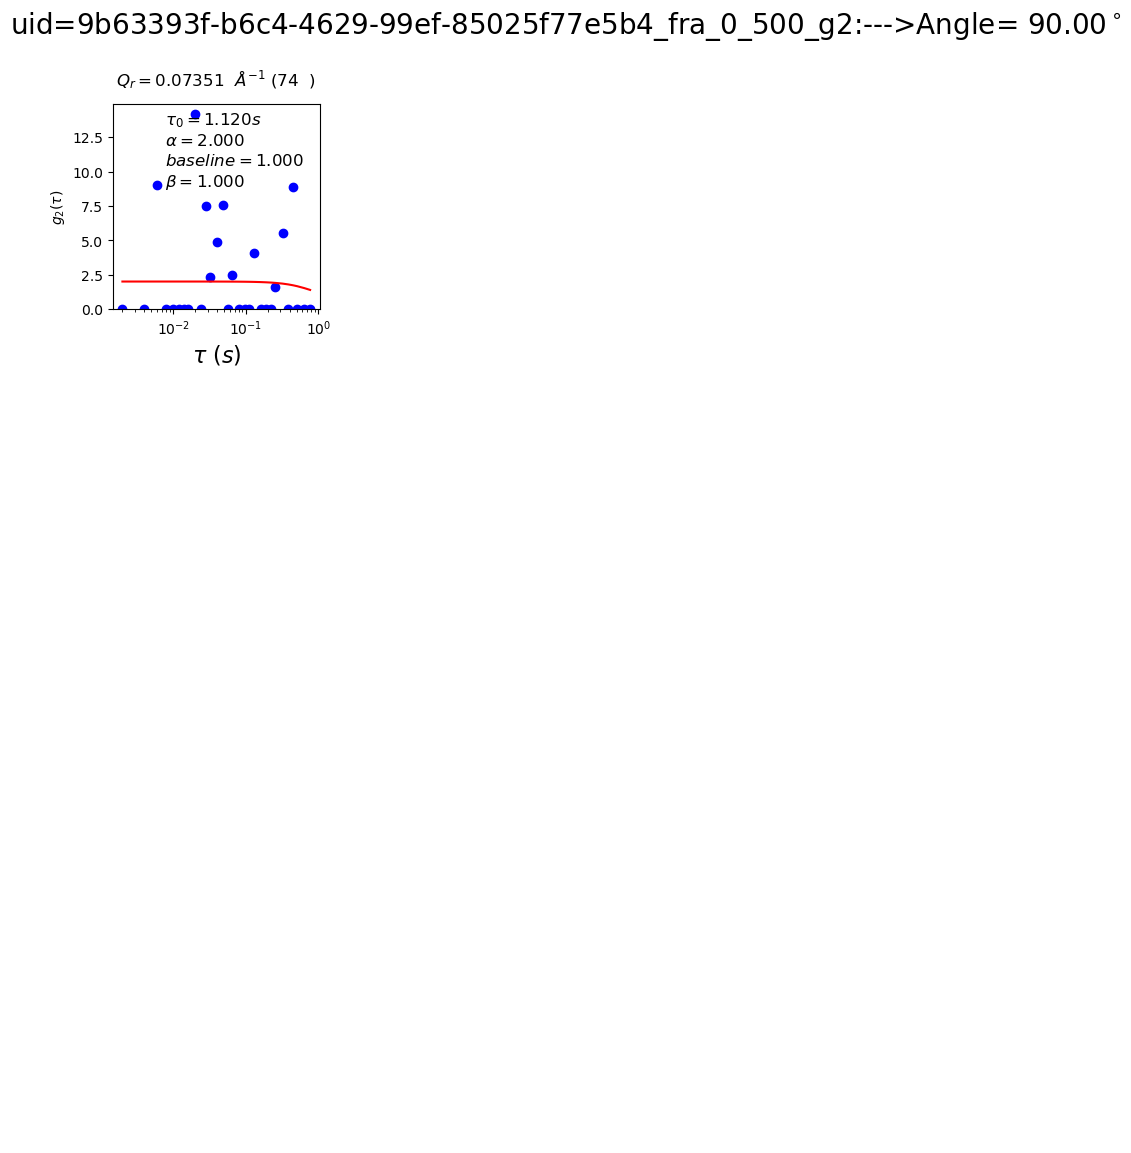

In [125]:
if run_two_time:
    if not g2b_fit_failed:
        plot_g2_general( g2_dict={1:g2b, 2:g2b_fit}, taus_dict={1:tausb, 2:tausb_fit}, vlim=[0.95, 1.05],
                qval_dict=dict(itertools.islice(qval_dict.items(),g2.shape[1])), fit_res= g2b_fit_result,  geometry=scat_geometry_,filename=uid_+'_g2', 
                    path= data_dir, function= fit_g2_func,  ylabel='g2', append_name=  '_b_fit')
    else:
        plot_g2_general( g2_dict={1:g2b,}, taus_dict={1:tausb, }, vlim=[0.95, 1.05],
                         qval_dict=dict(itertools.islice(qval_dict.items(),g2.shape[1])), fit_res= None,
                         geometry=scat_geometry_,filename=uid_+'_g2', 
                         path= data_dir, function= fit_g2_func,  ylabel='g2', append_name=  '')
                         

In [126]:
if run_two_time and not g2b_fit_failed :
    D0b, qrate_fit_resb = get_q_rate_fit_general(  dict(itertools.islice(qval_dict.items(),g2.shape[1])), g2b_fit_paras['relaxation_rate'],
                                        fit_range=[0, 10],  geometry= scat_geometry_ )

The fitted diffusion coefficient D0 is:  1.621e-03   A^2S-1
The fitted diffusion coefficient D0 is:  5.466e-02   A^2S-1
The fitted diffusion coefficient D0 is:  6.581e+00   A^2S-1
The fitted diffusion coefficient D0 is:  9.009e-04   A^2S-1


The fitted diffusion coefficient D0 is:  7.130e-03   A^2S-1
The fitted diffusion coefficient D0 is:  2.704e-03   A^2S-1
The fitted diffusion coefficient D0 is:  9.152e-03   A^2S-1
The fitted diffusion coefficient D0 is:  8.434e-02   A^2S-1


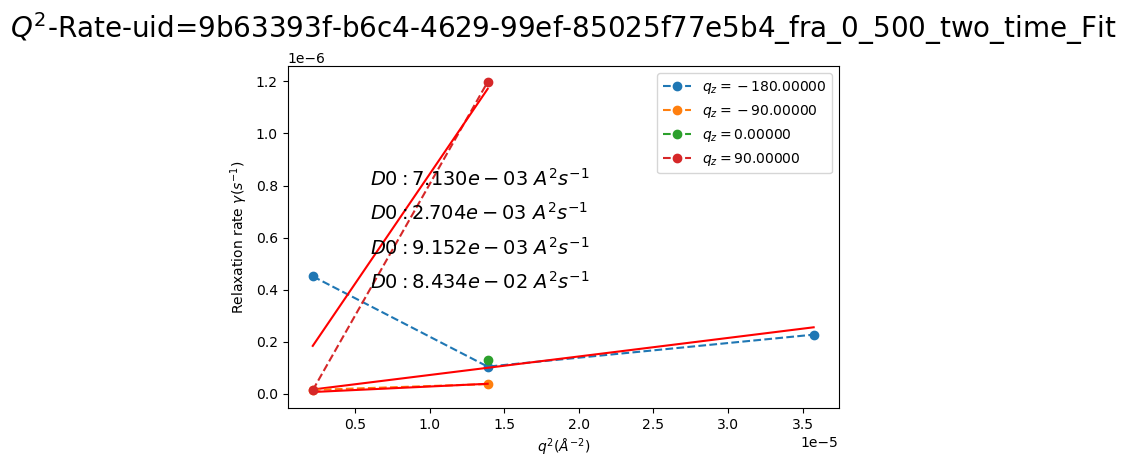

In [127]:
if run_two_time:
    try:
        if True:
            fs, fe = 0, 8
            #fs,fe=0, 6
            qval_dict_ = {k:qval_dict[k] for k in list(qval_dict.keys())[fs:fe]  }
            D0, qrate_fit_res = get_q_rate_fit_general(  qval_dict_, g2b_fit_paras['relaxation_rate'][fs:fe], 
                                                       geometry=  scat_geometry_ )
            plot_q_rate_fit_general( qval_dict_, g2b_fit_paras['relaxation_rate'][fs:fe],  qrate_fit_res, 
                                    geometry= scat_geometry_,uid=uid_ +'_two_time' , path= data_dir )
        elif False:
            D0, qrate_fit_res = get_q_rate_fit_general(  qval_dict, g2b_fit_paras['relaxation_rate'],
                                        fit_range=[0, 26],   geometry= scat_geometry_ )    
            plot_q_rate_fit_general( qval_dict, g2_fit_paras['relaxation_rate'],  qrate_fit_res,   
                                geometry=  scat_geometry_,uid=uid_ +'_two_time' ,
                                    show_fit=False, path= data_dir, plot_all_range=False) 
        else:
            ##plot log_q, log_rate
            plot_q_rate_general( qval_dict, g2b_fit_paras['relaxation_rate'],  
                                    geometry= scat_geometry_,uid=uid_ +'_two_time' , path= data_dir )

            plot_q_g2fitpara_general( qval_dict, g2b_fit_paras,  
                                    geometry= scat_geometry_,uid=uid_ +'_two_time' , path= data_dir )
    except:
        pass


The combined image is saved as: /nsls2/data/chx/proposals/2025-1/pass-315366/Results/9b63393f-b6c4-4629-99ef-85025f77e5b4/uid=9b63393f-b6c4-4629-99ef-85025f77e5b4_fra_0_500_g2_two_g2__joint.png


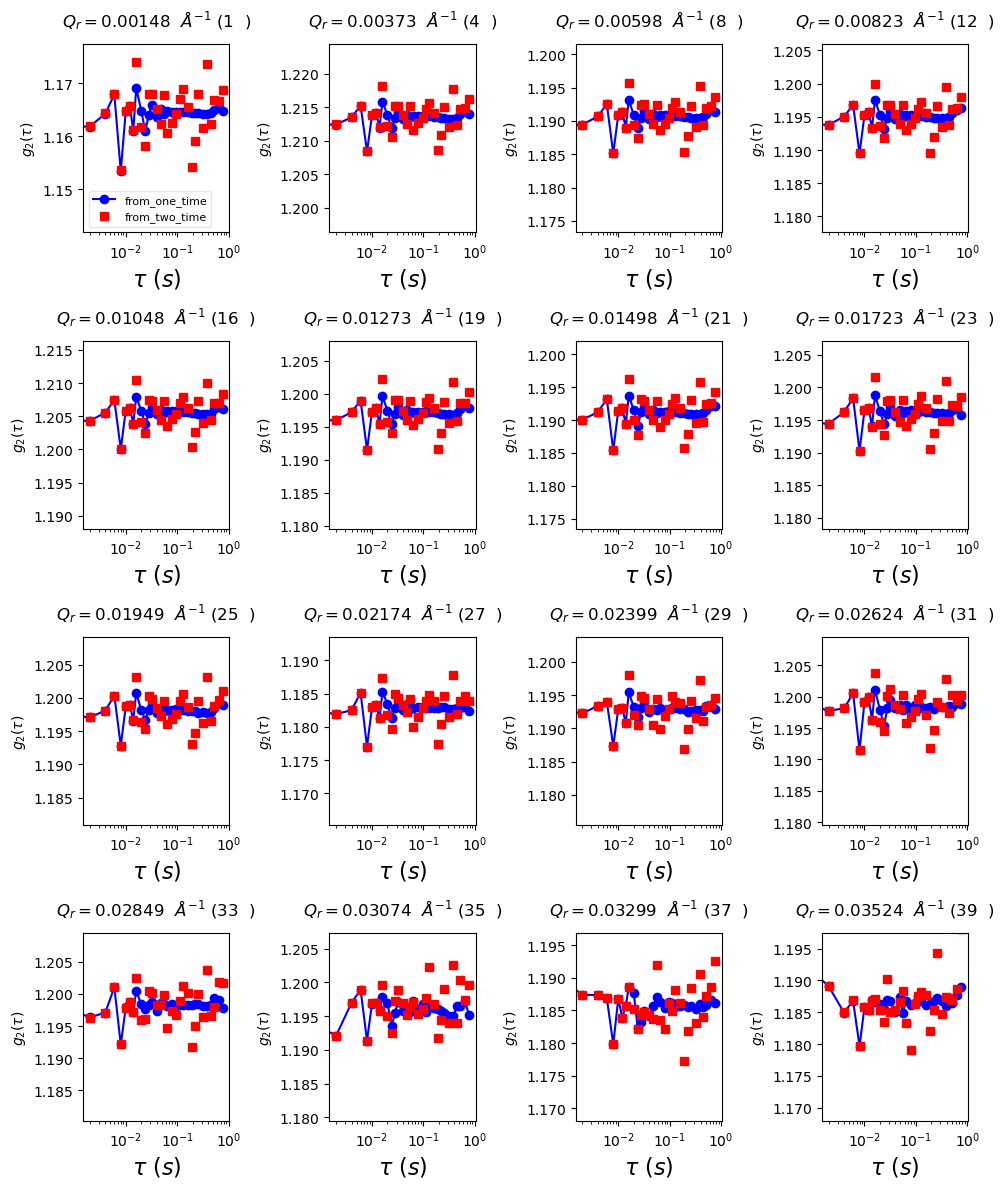

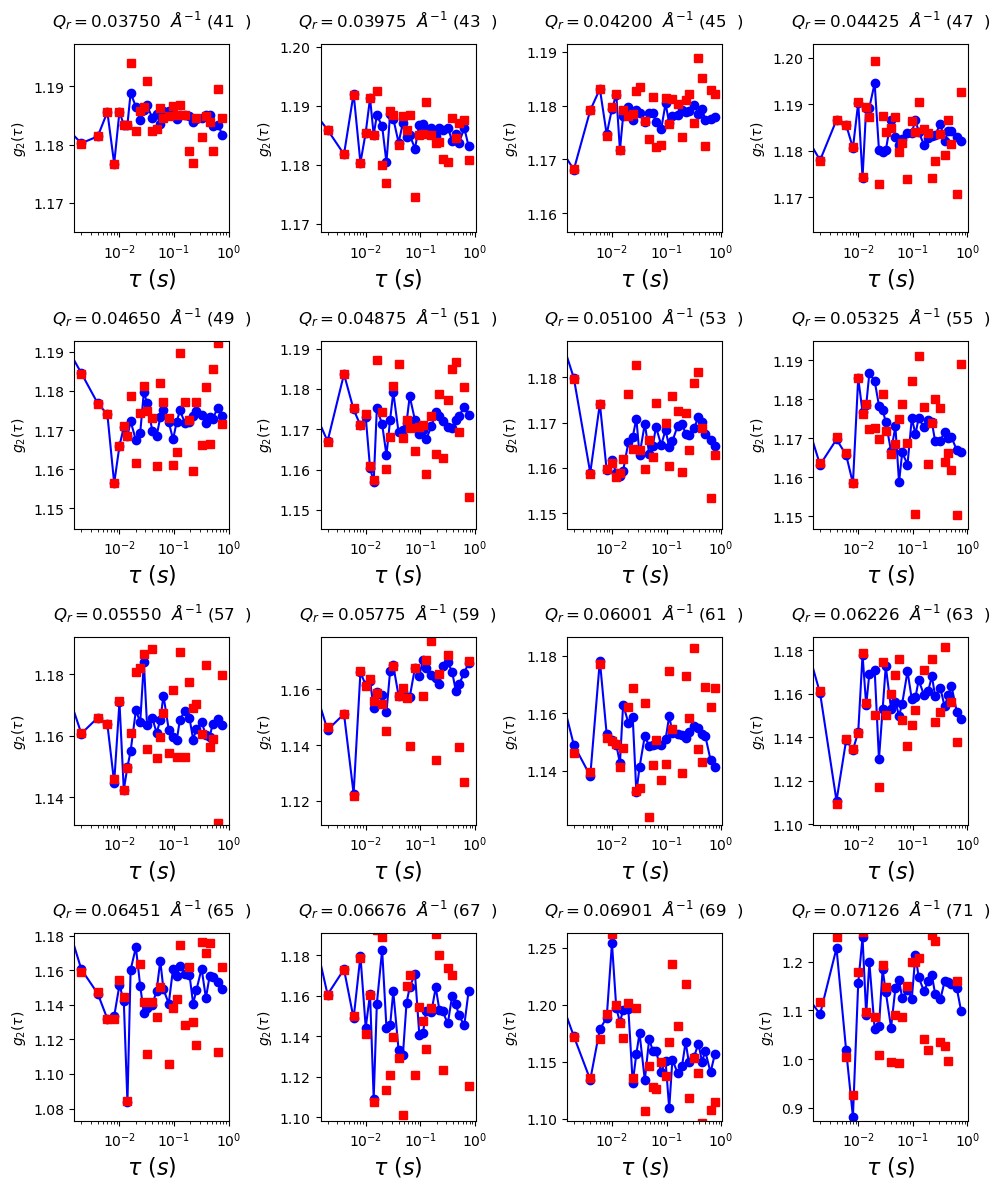

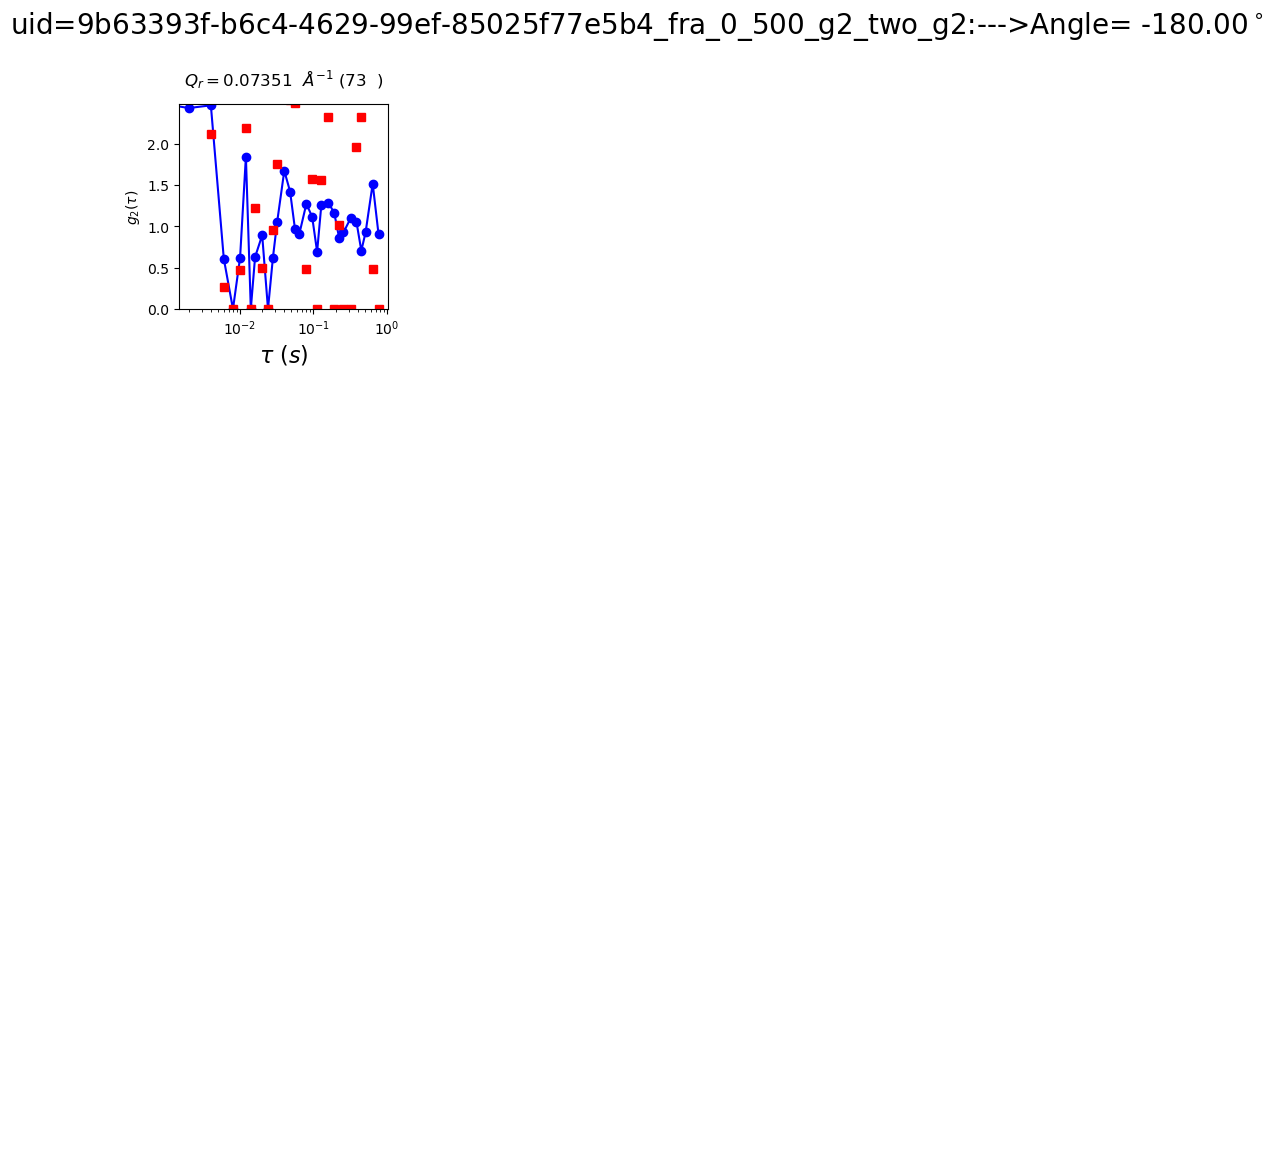

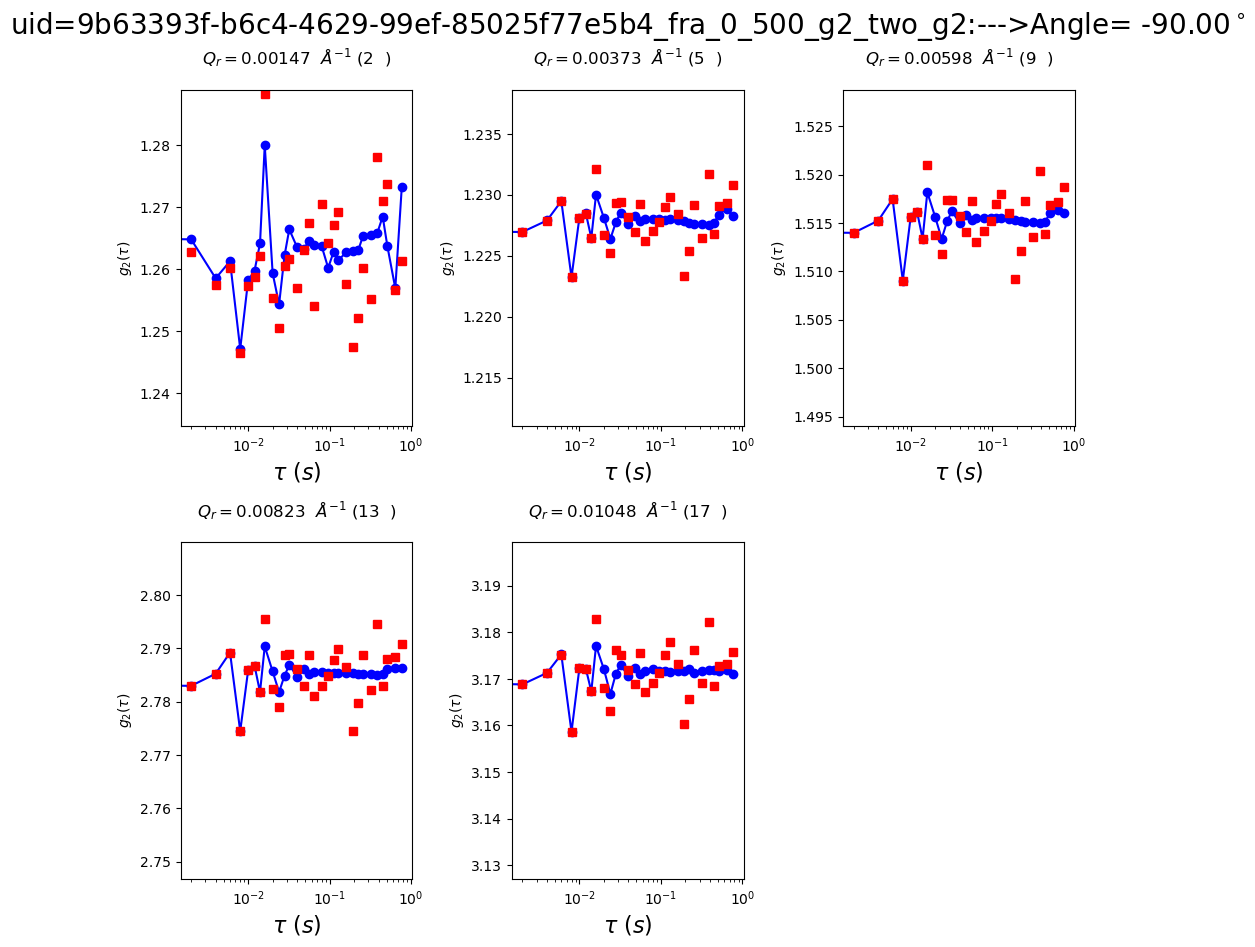

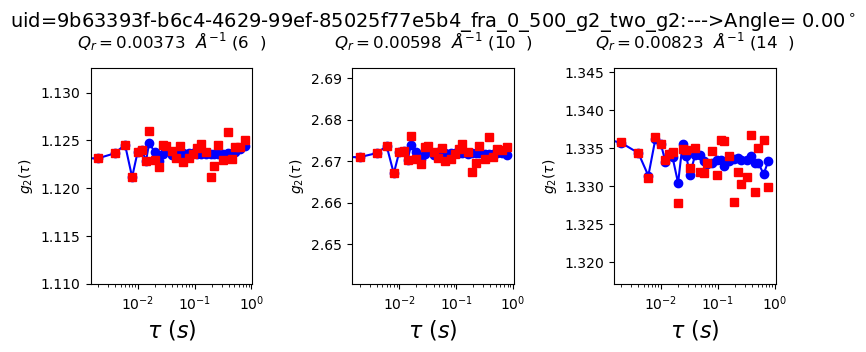

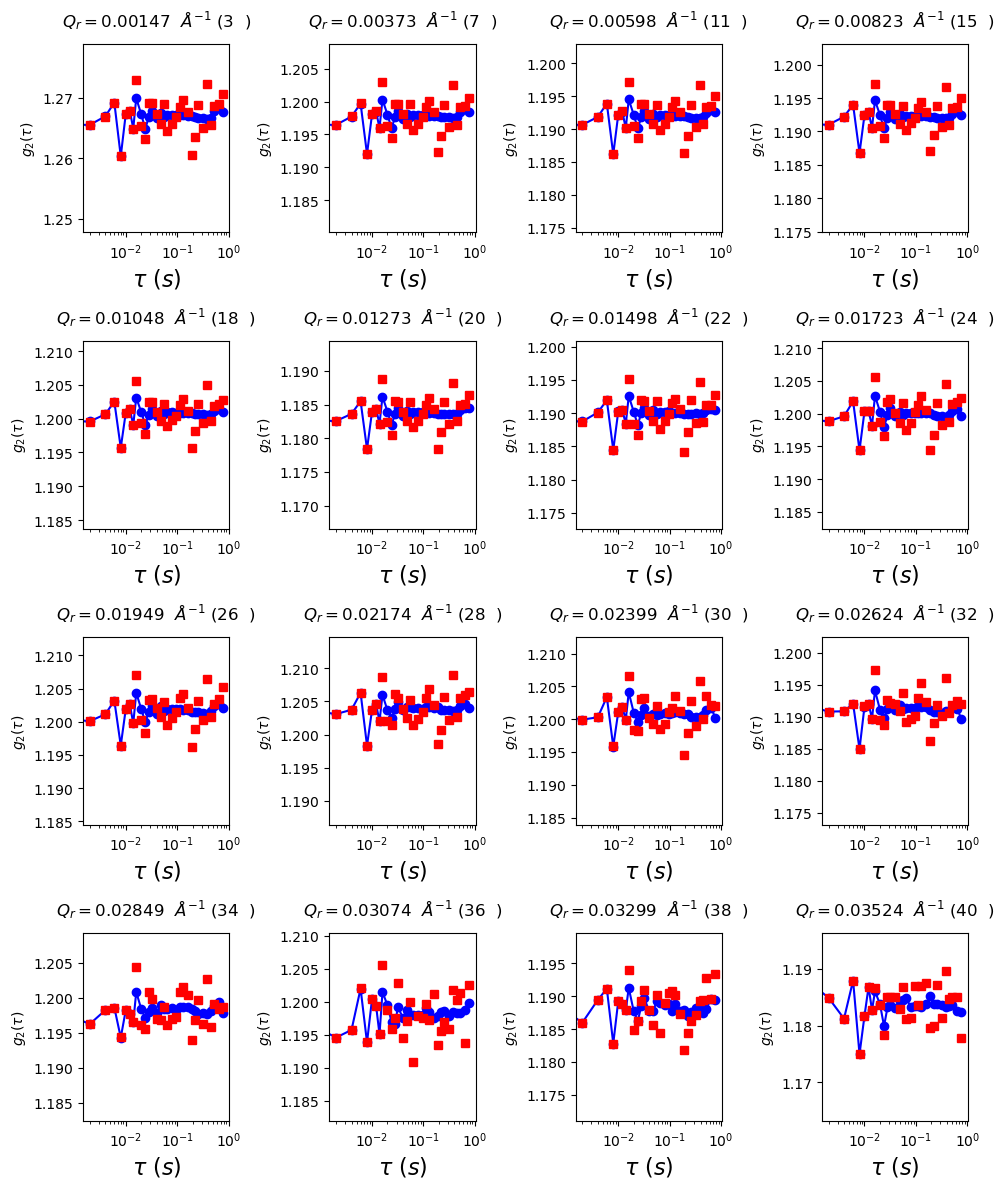

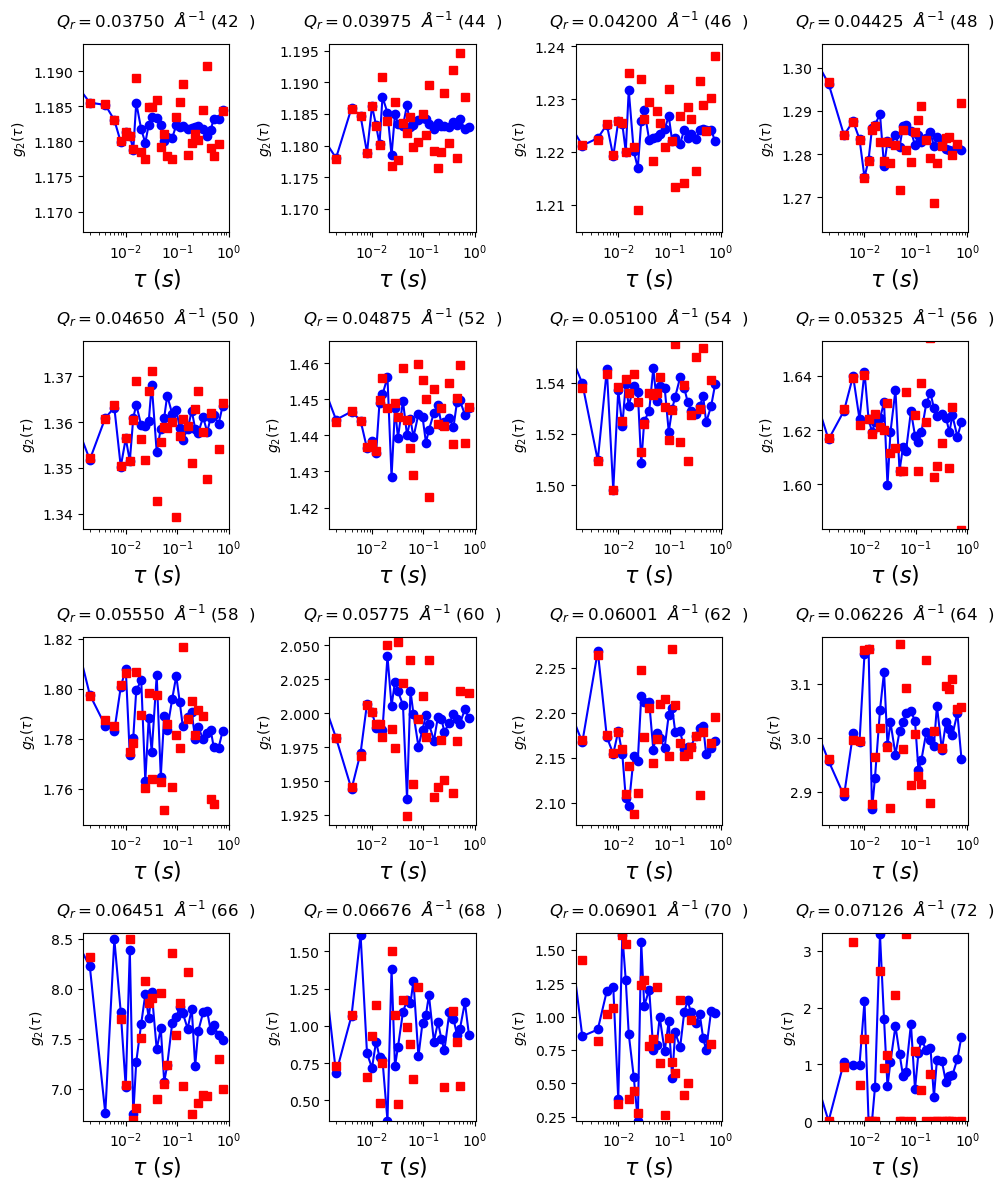

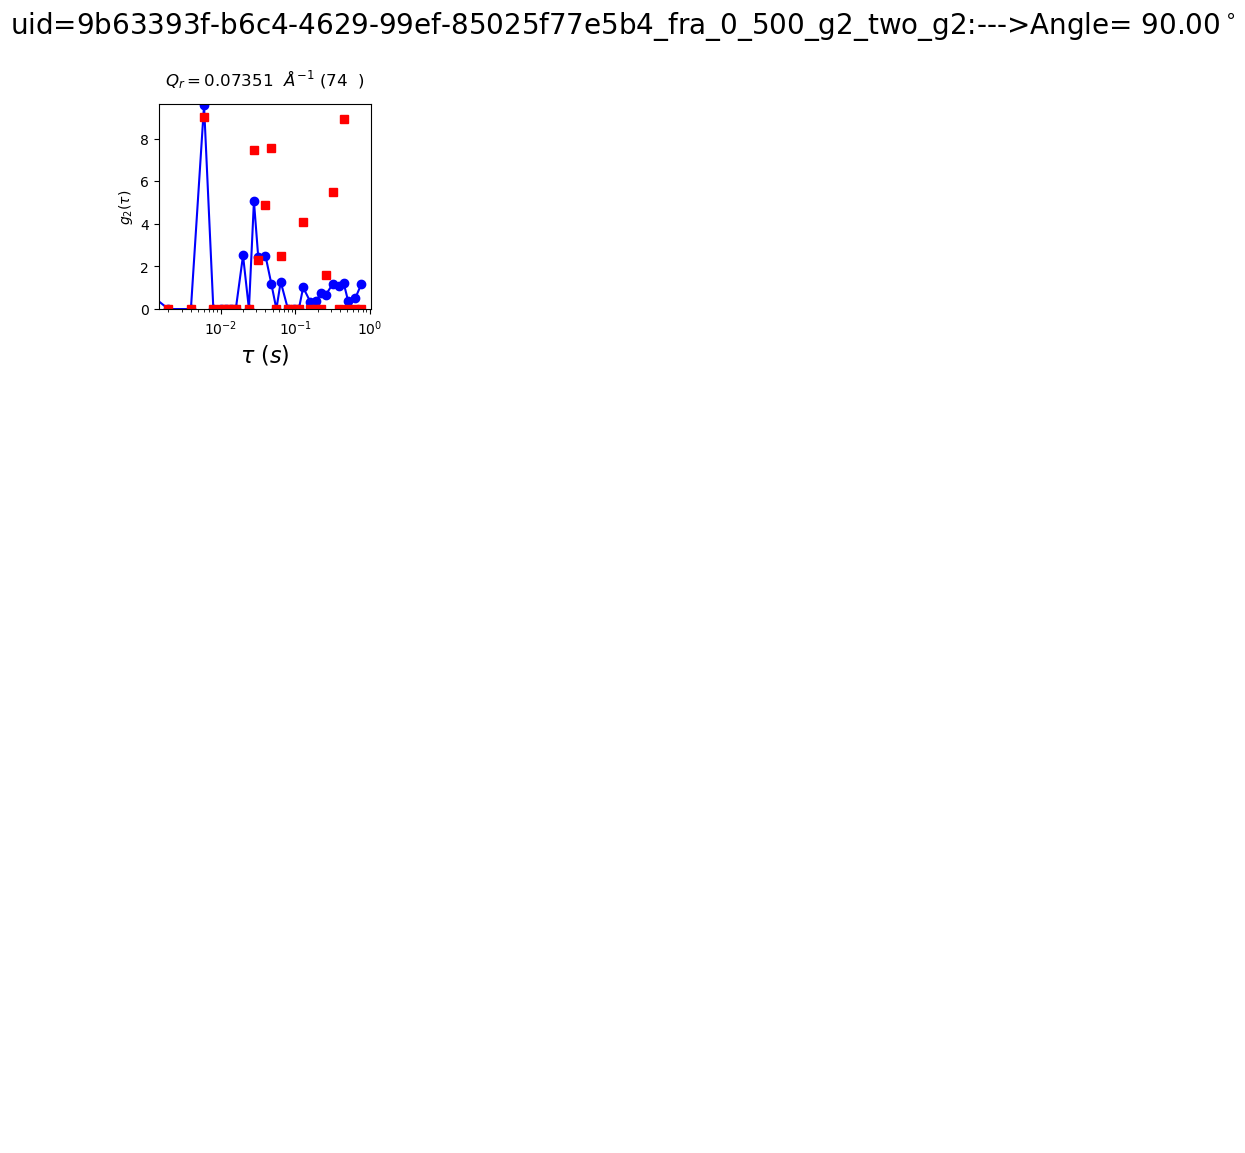

In [128]:
if run_two_time and run_one_time:
    plot_g2_general( g2_dict={1:g2, 2:g2b}, taus_dict={1:taus, 2:tausb},vlim=[0.99, 1.007],
                qval_dict=dict(itertools.islice(qval_dict.items(),g2.shape[1])), g2_labels=['from_one_time', 'from_two_time'],
            geometry=scat_geometry_,filename=uid_+'_g2_two_g2', path= data_dir, ylabel='g2', )

# Run Dose dependent analysis

In [129]:
if run_dose:
    get_two_time_mulit_uids( [uid], roi_mask,  norm= norm,  bin_frame_number=1, 
                        path= data_dir0, force_generate=False, compress_path =  cmp_path + '/' )

In [130]:
try:
    print( 'transmission: %s  exposure time: %s [s]'%(md['transmission'],exposuretime) )
except:
    md['transmission'] =1
    print( 'transmission: %s  exposure time: %s [s]'%(md['transmission'],exposuretime) )

transmission: 1.0  exposure time: 0.001997 [s]


In [131]:
if run_dose:
    N = len(imgs)
    print(N)
    #exposure_dose = md['transmission'] * exposuretime* np.int_([     N/16, N/8, N/4 ,N/2, 3*N/4, N*0.99 ])
    exposure_dose = md['transmission'] * exposuretime* np.int_([      N/8, N/4 ,N/2, 3*N/4, N*0.99 ])
    
    print( exposure_dose )

In [132]:
if run_dose:
    taus_uids, g2_uids = get_series_one_time_mulit_uids( [ uid ],  qval_dict, good_start=good_start,  
                    path= data_dir0, exposure_dose = exposure_dose,  num_bufs =8, save_g2= False,
                                                   dead_time = 0, trans = [ md['transmission'] ] )

In [133]:
if run_dose:    
    plot_dose_g2( taus_uids, g2_uids, ylim=[1.0, 1.2], vshift= 0.00,
                 qval_dict = qval_dict, fit_res= None,  geometry= scat_geometry_,
                 filename= '%s_dose_analysis'%uid_, 
                path= data_dir, function= None,  ylabel='g2_Dose', g2_labels= None, append_name=  '' )

In [134]:
if run_dose:
    qth_interest = 5
    plot_dose_g2( taus_uids, g2_uids, qth_interest= qth_interest, ylim=[0.98, 1.4], vshift= 0.00,
                 qval_dict = qval_dict, fit_res= None,  geometry= scat_geometry_,
                 filename= '%s_dose_analysis'%uidstr, 
                path= data_dir, function= None,  ylabel='g2_Dose', g2_labels= None, append_name=  '' )

In [135]:
if track_progress:
    if settings_dict_['run_two_time']:
        update_prog_dict_run_XPCS_SAXS(prog_dict_file,process_id,progress_key='run_two_time', progress='stop',start_time=None, stop_time=time.time(), verbose=True)
    if settings_dict_['xsvs']:
        update_prog_dict_run_XPCS_SAXS(prog_dict_file,process_id,progress_key='xsvs', progress='start',start_time=time.time(), stop_time=None, verbose=True)

# Four Time Correlation

In [136]:
if run_four_time:
    t0=time.time()
    g4 = get_four_time_from_two_time(g12b, g2=g2b)[:int(max_taus)]
    run_time(t0)

In [137]:
if run_four_time:
    taus4 = np.arange( g4.shape[0])*timeperframe        
    g4_pds = save_g2_general( g4, taus=taus4, qr=np.array( list( qval_dict.values() ) )[:,0],
                             qz=None, uid=uid_ +'_g4.csv', path= data_dir, return_res=True )

In [138]:
if run_four_time:
    plot_g2_general( g2_dict={1:g4}, taus_dict={1:taus4},vlim=[0.95, 1.05], qval_dict=qval_dict, fit_res= None, 
                geometry=scat_geometry_,filename=uid_+'_g4',path= data_dir,   ylabel='g4')

# Speckle Visiblity

In [139]:
if run_xsvs:    
    max_cts = get_max_countc(FD, roi_mask )    
    #max_cts = 15 #for eiger 500 K
    qind, pixelist = roi.extract_label_indices(   roi_mask  )
    noqs = len( np.unique(qind) )
    nopr = np.bincount(qind, minlength=(noqs+1))[1:]
    #time_steps = np.array( utils.geometric_series(2,   len(imgs)   ) )
    time_steps = [0,1]  #only run the first two levels
    num_times = len(time_steps)    
    times_xsvs = exposuretime + (2**(  np.arange( len(time_steps) ) ) -1 ) * timeperframe   
    print( 'The max counts are: %s'%max_cts )


### Do histogram 

In [140]:
if run_xsvs:
    if roi_avg is  None:
        times_roi, mean_int_sets = cal_each_ring_mean_intensityc(FD, roi_mask, timeperframe = None,  ) 
        roi_avg = np.average( mean_int_sets, axis=0)
    
    t0=time.time()
    spec_bins, spec_his, spec_std, spec_sum  =  xsvsp( FD, np.int_(roi_mask), norm=None,
                max_cts=int(max_cts+2),  bad_images=bad_frame_list, only_two_levels=True )    
    spec_kmean =  np.array(  [roi_avg * 2**j for j in  range( spec_his.shape[0] )] )
    run_time(t0)
    spec_pds =  save_bin_his_std( spec_bins, spec_his, spec_std, filename=uid_+'_spec_res.csv', path=data_dir ) 

### Do historam fit by negtive binominal function with maximum likehood method

In [141]:
if run_xsvs:    
    ML_val, KL_val,K_ = get_xsvs_fit(  spec_his, spec_sum, spec_kmean, 
                        spec_std, max_bins=2, fit_range=[1,60], varyK= False  )
    #print( 'The observed average photon counts are: %s'%np.round(K_mean,4))
    #print( 'The fitted average photon counts are: %s'%np.round(K_,4)) 
    print( 'The difference sum of average photon counts between fit and data are: %s'%np.round( 
            abs(np.sum( spec_kmean[0,:] - K_ )),4))
    print( '#'*30)
    qth=   0 
    print( 'The fitted M for Qth= %s are: %s'%(qth, ML_val[qth]) )
    print( K_[qth])
    print( '#'*30)

## Plot fit results

In [142]:
if run_xsvs:   
    qr = [qval_dict[k][0] for k in list(qval_dict.keys()) ]
    plot_xsvs_fit(  spec_his, ML_val, KL_val, K_mean = spec_kmean, spec_std=spec_std,
                  xlim = [0,10], vlim =[.9, 1.1],
        uid=uid_, qth= qth_interest, logy= True, times= times_xsvs, q_ring_center=qr, path=data_dir)
    
    plot_xsvs_fit(  spec_his, ML_val, KL_val, K_mean = spec_kmean, spec_std = spec_std,
                  xlim = [0,15], vlim =[.9, 1.1],
        uid=uid_, qth= None, logy= True, times= times_xsvs, q_ring_center=qr, path=data_dir )

### Get contrast

In [143]:
if run_xsvs:
    contrast_factorL = get_contrast( ML_val)
    spec_km_pds = save_KM(  spec_kmean, KL_val, ML_val, qs=qr, level_time=times_xsvs, uid=uid_, path = data_dir )
    #spec_km_pds

### Plot contrast with g2 results

In [144]:
if run_xsvs:    
    plot_g2_contrast( contrast_factorL, g2b, times_xsvs, tausb, qr, 
                     vlim=[0.8,1.2], qth = qth_interest, uid=uid_,path = data_dir, legend_size=14)

    plot_g2_contrast( contrast_factorL, g2b, times_xsvs, tausb, qr, 
                     vlim=[0.8,1.2], qth = None, uid=uid_,path = data_dir, legend_size=4)

In [145]:
if track_progress:
    if settings_dict_['xsvs']:
        update_prog_dict_run_XPCS_SAXS(prog_dict_file,process_id,progress_key='xsvs', progress='stop',start_time=None, stop_time=time.time(), verbose=True)
    update_prog_dict_run_XPCS_SAXS(prog_dict_file,process_id,progress_key='save data and report', progress='start',start_time=time.time(), stop_time=None, verbose=True)

# Export Results to a HDF5 File

In [146]:
md['detector_mask_file']=detector_mask_path+detector_mask_filename
md['det_mask_dict'] = det_mask_dict
md['polygon_mask']= polygon_dict
md['roi_mask_file']= fp
md['mask'] = mask
#md['NOTEBOOK_FULL_PATH'] =  data_dir + get_current_pipeline_fullpath(NFP).split('/')[-1]
md['good_start'] = good_start
md['bad_frame_list'] = bad_frame_list
md['avg_img'] = avg_img
md['roi_mask'] = roi_mask
md['mask_outliers'] = mask_outliers
if mask_outliers:
    md['outlier_threshold'] = outlier_threshold
    md['maximum_outlier_fraction'] = maximum_outlier_fraction
md['setup_pargs'] = setup_pargs
if scat_geometry == 'gi_saxs':        
    md['Qr'] = Qr
    md['Qz'] = Qz
    md['qval_dict'] = qval_dict
    md['beam_center_x'] =  inc_x0
    md['beam_center_y']=   inc_y0
    md['beam_refl_center_x'] = refl_x0
    md['beam_refl_center_y'] = refl_y0


elif scat_geometry == 'gi_waxs':
    md['beam_center_x'] =  center[1]
    md['beam_center_y']=  center[0]
else:
    md['qr']= qr
    #md['qr_edge'] = qr_edge
    md['qval_dict'] = qval_dict
    md['beam_center_x'] =  center[1]
    md['beam_center_y']=  center[0]            

md['beg'] = FD.beg
md['end'] = FD.end
md['qth_interest'] = qth_interest
md['metadata_file'] = data_dir + 'uid=%s_md.pkl'%uid

md['beg_OneTime'] = good_start_g2
md['end_OneTime'] = good_end_g2

psave_obj(  md, data_dir + 'uid=%s_md.pkl'%uid ) #save the setup parameters
save_dict_csv( md,  data_dir + 'uid=%s_md.csv'%uid, 'w')

Exdt = {} 
if scat_geometry == 'gi_saxs':  
    for k,v in zip( ['md', 'roi_mask','qval_dict','avg_img','mask','pixel_mask', 'imgsum', 'bad_frame_list', 'qr_1d_pds'], 
                [md,    roi_mask, qval_dict, avg_img,mask,pixel_mask, imgsum, bad_frame_list, qr_1d_pds] ):
        Exdt[ k ] = v
elif scat_geometry == 'saxs': 
    for k,v in zip( ['md', 'q_saxs', 'iq_saxs','iqst','qt','roi_mask','qval_dict','avg_img','mask','pixel_mask', 'imgsum', 'bad_frame_list'], 
                [md, q_saxs, iq_saxs, iqst, qt,roi_mask, qval_dict, avg_img,mask,pixel_mask, imgsum, bad_frame_list] ):
        Exdt[ k ] = v
elif scat_geometry == 'gi_waxs': 
    for k,v in zip( ['md', 'roi_mask','qval_dict','avg_img','mask','pixel_mask', 'imgsum', 'bad_frame_list'], 
                [md,       roi_mask, qval_dict, avg_img,mask,pixel_mask, imgsum, bad_frame_list] ):
        Exdt[ k ] = v
        
if run_waterfall:Exdt['wat'] =  wat
if run_t_ROI_Inten:Exdt['times_roi'] = times_roi;Exdt['mean_int_sets']=mean_int_sets
if run_one_time:
    if run_invariant_analysis:
        for k,v in zip( ['taus','g2','g2_fit_paras', 'time_stamp','invariant'], [taus,g2,g2_fit_paras,time_stamp,invariant] ):Exdt[ k ] = v
    else:
        for k,v in zip( ['taus','g2','g2_fit_paras'  ], [taus,g2,g2_fit_paras ] ):Exdt[ k ] = v
            
if run_two_time:
    for k,v in zip( ['tausb','g2b','g2b_fit_paras', 'g12b'], [tausb,g2b,g2b_fit_paras,g12b] ):Exdt[ k ] = v
    #for k,v in zip( ['tausb','g2b','g2b_fit_paras', ], [tausb,g2b,g2b_fit_paras] ):Exdt[ k ] = v    
if run_dose:
    for k,v in zip( [ 'taus_uids', 'g2_uids' ], [taus_uids, g2_uids] ):Exdt[ k ] = v
if run_four_time:
    for k,v in zip( ['taus4','g4'], [taus4,g4] ):Exdt[ k ] = v
if run_xsvs:
    for k,v in zip( ['spec_kmean','spec_pds','times_xsvs','spec_km_pds','contrast_factorL'], 
                   [ spec_kmean,spec_pds,times_xsvs,spec_km_pds,contrast_factorL] ):Exdt[ k ] = v 

In [147]:
export_xpcs_results_to_h5( 'uid=%s_%s_Res%s.h5'%(md['uid'],q_mask_name,hdf5_name_extension), data_dir, export_dict = Exdt )
#extract_dict = extract_xpcs_results_from_h5( filename = 'uid=%s_Res.h5'%md['uid'], import_dir = data_dir )


The xpcs analysis results are exported to /nsls2/data/chx/proposals/2025-1/pass-315366/Results/9b63393f-b6c4-4629-99ef-85025f77e5b4/ with filename as uid=9b63393f-b6c4-4629-99ef-85025f77e5b4_phi_4x_20deg_Res.h5


In [148]:
try:
    from pyCHX.chx_generic_functions import append_txtfile
    outp = default_dir+'%s/%s/'%(md['cycle'],username)
    append_txtfile( filename =  outp  + username + '.lst', 
                   data =  np.array( [ outp +    'Results/' + md['uid'] + '/uid=%s__Res.h5'%md['uid']]))
except:
    print('ERROR: unable to append output textfile for this uid.')

# Create a PDF Report

In [149]:
pdf_out_dir = data_dir0

pdf_filename = "XPCS_Analysis_Report2_for_uid=%s%s%s.pdf"%(uid,pdf_version,q_mask_name)
if run_xsvs:
    pdf_filename = "XPCS_XSVS_Analysis_Report_for_uid=%s%s%s.pdf"%(uid,pdf_version,q_mask_name)

In [150]:
# cheating here a little: the function argument 'False' hardcodes the absence of the form factor fit
make_pdf_report( data_dir, uid, pdf_out_dir, pdf_filename, username, 
                   False,run_one_time, run_two_time, run_four_time, run_xsvs, run_dose,
                report_type= scat_geometry, report_invariant= run_invariant_analysis,
               md = md )



uid=9b63393f-b6c4-4629-99ef-85025f77e5b4_fra_0_500_g2_two_g2__joint.png

****************************************
The pdf report is created with filename as: /nsls2/data/chx/proposals/2025-1/pass-315366/Results/XPCS_Analysis_Report2_for_uid=9b63393f-b6c4-4629-99ef-85025f77e5b4_2025-03-27_12-10-32phi_4x_20deg.pdf
****************************************


In [151]:
if track_progress:
    update_prog_dict_run_XPCS_SAXS(prog_dict_file,process_id,progress_key='save data and report', progress='stop',start_time=None, stop_time=time.time(), verbose=True)

## Attach the PDF report to Olog 

In [152]:
if att_pdf_report:
    lops=0
    while lops<5:
        try:
            update_olog_uid_with_file( uid[:6], text='Add XPCS Analysis PDF Report', 
                              filename=pdf_out_dir + pdf_filename, append_name='_R1' )
            lops=5
        except:
            print("Failed to attach PDF report to Olog...try again in 10s")
            time.sleep(10)
            lops+=1
            if lops == 5:
                print("Failed final attempt to attach PDF to Olog!")
                

The url=https://epics-services-chx.nsls2.bnl.local:38981/Olog was successfully updated with Add XPCS Analysis PDF Report and with the attachments


## Save the OAV images

In [153]:
if save_oavs:
    try:
        #os.environ['HTTPS_PROXY'] = 'https://proxy:8888'
        #os.environ['no_proxy'] = 'cs.nsls2.local,localhost,127.0.0.1'
        update_olog_uid_with_file( uid[:6], text='Add OVA images', 
                              filename= data_dir + 'uid=%s_OVA_images.png'%uid, append_name='_img' )
    except:
        print('failed to update Olog with OAV images')

### giving file permissions ..

In [154]:
data_dir0

'/nsls2/data/chx/proposals/2025-1/pass-315366/Results/'

In [155]:
staff=['fluerasu','lwiegart','xmchen','jgoodrich']

current_dir = !pwd
respipelines_path = data_dir0  #this is actually the current directory..
for user in users + staff:
    !setfacl -R -m u:{user}:rwx {data_dir0}
    !setfacl -R -m u:{user}:rwx {respipelines_path}        
    print('Setting rwx rights for user %s to:\n %s \n %s \n'%(user,data_dir0,respipelines_path))        


Setting rwx rights for user fluerasu to:
 /nsls2/data/chx/proposals/2025-1/pass-315366/Results/ 
 /nsls2/data/chx/proposals/2025-1/pass-315366/Results/ 

Setting rwx rights for user lwiegart to:
 /nsls2/data/chx/proposals/2025-1/pass-315366/Results/ 
 /nsls2/data/chx/proposals/2025-1/pass-315366/Results/ 

Setting rwx rights for user xmchen to:
 /nsls2/data/chx/proposals/2025-1/pass-315366/Results/ 
 /nsls2/data/chx/proposals/2025-1/pass-315366/Results/ 

Setting rwx rights for user jgoodrich to:
 /nsls2/data/chx/proposals/2025-1/pass-315366/Results/ 
 /nsls2/data/chx/proposals/2025-1/pass-315366/Results/ 



# The End!